
# Comparación de dos corridas de inversión de perturbación F3+nexp

Este notebook compara tres niveles de reconstrucción usando el background **old ASLS 13341497** cargado desde HDF5:

1. **Seed original de la primera corrida**: se recalcula con el forward model porque la primera corrida no guardó la serie temporal del seed.
2. **Best de la primera corrida**: leído directamente desde `new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_results_14760926.h5`.
3. **Best de la segunda corrida**: leído directamente desde `new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_seed_from_14760926_results_15175350.h5`.

La comparación se hace contra los **datos reales corregidos** usados como target:

```text
A_target_corr   = target_A_raw   + 19 dB
phi_target_corr = target_phi_raw - 210 deg
```

La única serie recalculada es el seed original de la primera corrida, porque ese HDF5 no la guardó. Todo lo demás se lee de los HDF5.


In [1]:

# ============================================================
# Rutas de trabajo
# ============================================================

FIRST_H5 = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_results_14760926.h5"
SECOND_H5 = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_seed_from_14760926_results_15175350.h5"

FIRST_OUT = "new_perturbation_F3_oldASLS_BG13341497.14760926.out"
SECOND_OUT = "new_perturbation_F3_oldASLS_restart14760926.15175350.out"

BACKGROUND_H5 = "new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5"

# Script usado para reconstruir el setup de la primera corrida.
# Se corta antes de BlackBoxOptim, así que NO corre la optimización.
SOURCE_SCRIPT_FIRST = "new-perturbation-data-inversion-bbo_F3_nexp_fixed_CLEAN_v3_oldASLS_BG_from_H5.jl"

FIG_DIR = "figures_perturbation_F3_oldASLS_two_runs"
mkpath(FIG_DIR)

# Si los archivos están en otra ruta, cambia estas variables aquí.
# ENV["BACKGROUND_H5"] = "/ruta/al/background.h5"


"figures_perturbation_F3_oldASLS_two_runs"

In [2]:

# ============================================================
# Paquetes y utilidades generales
# ============================================================

using HDF5
using Dates
using Statistics
using Printf
using DataFrames
import CairoMakie
const CM = CairoMakie

function h5exists(path, key)
    h5open(path, "r") do f
        return haskey(f, key)
    end
end

function readvec(path, key)
    h5open(path, "r") do f
        return Float64.(vec(read(f[key])))
    end
end

function readscalar(path, key)
    h5open(path, "r") do f
        return Float64(read(f[key]))
    end
end

function read_attr(path, key; default=nothing)
    h5open(path, "r") do f
        attrs = HDF5.attributes(f)
        if haskey(attrs, key)
            return read(attrs[key])
        else
            return default
        end
    end
end

function attr_string(path, key; default="")
    x = read_attr(path, key; default=default)
    if x === nothing
        return default
    elseif x isa Vector{UInt8}
        return String(x)
    elseif x isa AbstractString
        return String(x)
    else
        return string(x)
    end
end

function attr_float(path, key; default=NaN)
    x = read_attr(path, key; default=default)
    try
        return Float64(x)
    catch
        return default
    end
end

function hour_from_unix(tunix)
    tunix = Float64.(tunix)
    if median(tunix) > 1e12
        dt = unix2datetime.(round.(Int, tunix ./ 1000.0))
    else
        dt = unix2datetime.(round.(Int, tunix))
    end
    return Dates.hour.(dt) .+ Dates.minute.(dt) ./ 60 .+ Dates.second.(dt) ./ 3600 .+ Dates.millisecond.(dt) ./ 3.6e6
end

function chi2_channel(model, target)
    scale = sum((target .- mean(target)).^2) + 1e-12
    return sum((model .- target).^2) / scale
end

function rmse_channel(model, target)
    return sqrt(mean((model .- target).^2))
end

function metrics_pair(A_model, phi_model, A_target, phi_target)
    chiA = chi2_channel(A_model, A_target)
    chiP = chi2_channel(phi_model, phi_target)
    return (
        chiA = chiA,
        chiP = chiP,
        chiT = chiA + chiP,
        rmseA = rmse_channel(A_model, A_target),
        rmseP = rmse_channel(phi_model, phi_target),
    )
end

function label_metrics(prefix, m)
    return @sprintf(
        "%s (χ²_A=%.4f, χ²_ϕ=%.4f, χ²_tot=%.4f)",
        prefix,
        m.chiA,
        m.chiP,
        m.chiT,
    )
end

function safe_readvec(path, keys)
    for key in keys
        if h5exists(path, key)
            return readvec(path, key), key
        end
    end
    error("No encontré ninguna llave válida en $(path). Probé: $(keys)")
end


safe_readvec (generic function with 1 method)

In [3]:

# ============================================================
# Leer primera corrida
# ============================================================

@assert isfile(FIRST_H5) "No existe FIRST_H5 = $(FIRST_H5)"

amp_offset_1 = attr_float(FIRST_H5, "amp_offset_db_used"; default=19.0)
phi_offset_1 = attr_float(FIRST_H5, "phi_offset_deg_used"; default=-210.0)

println("Primera corrida:")
println("  H5: ", FIRST_H5)
println("  background: ", attr_string(FIRST_H5, "background_source_h5"))
@printf("  offsets: A %+g dB, phi %+g deg\n", amp_offset_1, phi_offset_1)

timestamps_1 = readvec(FIRST_H5, "timestamps")
t_hours_1 = hour_from_unix(timestamps_1)

target_A_raw_1 = readvec(FIRST_H5, "target_A")
target_phi_raw_1 = readvec(FIRST_H5, "target_phi")

target_A_corr_1 = target_A_raw_1 .+ amp_offset_1
target_phi_corr_1 = target_phi_raw_1 .+ phi_offset_1

initial_params_1 = readvec(FIRST_H5, "initial_params")
best_params_1 = readvec(FIRST_H5, "reco_params")

A_best_1 = readvec(FIRST_H5, "A_reco")
phi_best_1 = readvec(FIRST_H5, "phi_reco")

println("  initial_params_1 = ", initial_params_1)
println("  best_params_1    = ", best_params_1)
println("  N puntos         = ", length(t_hours_1))


Primera corrida:
  H5: new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_results_14760926.h5
  background: new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
  offsets: A +19 dB, phi -210 deg
  initial_params_1 = [20.0, 1609.4725200000003, 190.5781464, 1248.558552, 789.6851280000001, 85.0, 10.0]
  best_params_1    = [20.07315293468811, 1626.6769940467618, 209.33767699958398, 1444.7086860708544, 767.343637934929, 84.39753917983758, 10.363831465971161]
  N puntos         = 17


In [4]:

# ============================================================
# Leer segunda corrida
# ============================================================

@assert isfile(SECOND_H5) "No existe SECOND_H5 = $(SECOND_H5)"

amp_offset_2 = attr_float(SECOND_H5, "amp_offset_db_used"; default=19.0)
phi_offset_2 = attr_float(SECOND_H5, "phi_offset_deg_used"; default=-210.0)

println("Segunda corrida:")
println("  H5: ", SECOND_H5)
println("  seed source: ", attr_string(SECOND_H5, "seed_source_h5"))
println("  seed type  : ", attr_string(SECOND_H5, "seed_source_type"))
@printf("  offsets: A %+g dB, phi %+g deg\n", amp_offset_2, phi_offset_2)

timestamps_2 = readvec(SECOND_H5, "timestamps")
t_hours_2 = hour_from_unix(timestamps_2)

target_A_corr_2, key_A_target_2 = safe_readvec(SECOND_H5, ["targets/target_A_corr", "target_A_corr"])
target_phi_corr_2, key_phi_target_2 = safe_readvec(SECOND_H5, ["targets/target_phi_corr", "target_phi_corr"])

initial_params_2, key_initial_2 = safe_readvec(SECOND_H5, ["initial/params", "initial_params"])
best_params_2, key_best_2 = safe_readvec(SECOND_H5, ["reconstruction/params", "reco_params"])

A_seed_2, key_A_seed_2 = safe_readvec(SECOND_H5, ["initial/A_model", "A_seed"])
phi_seed_2, key_phi_seed_2 = safe_readvec(SECOND_H5, ["initial/phi_model", "phi_seed"])

A_best_2, key_A_best_2 = safe_readvec(SECOND_H5, ["reconstruction/A_model", "A_reco"])
phi_best_2, key_phi_best_2 = safe_readvec(SECOND_H5, ["reconstruction/phi_model", "phi_reco"])

println("  target keys: ", key_A_target_2, " / ", key_phi_target_2)
println("  seed keys:   ", key_A_seed_2, " / ", key_phi_seed_2)
println("  best keys:   ", key_A_best_2, " / ", key_phi_best_2)
println("  initial_params_2 = ", initial_params_2)
println("  best_params_2    = ", best_params_2)
println("  N puntos         = ", length(t_hours_2))


Segunda corrida:
  H5: new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_seed_from_14760926_results_15175350.h5
  seed source: new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_results_14760926.h5
  seed type  : previous_perturbation_inversion:reco_params
  offsets: A +19 dB, phi -210 deg
  target keys: targets/target_A_corr / targets/target_phi_corr
  seed keys:   initial/A_model / initial/phi_model
  best keys:   reconstruction/A_model / reconstruction/phi_model
  initial_params_2 = [20.07315293468811, 1626.6769940467618, 209.33767699958398, 1444.7086860708544, 767.343637934929, 84.39753917983758, 10.363831465971161]
  best_params_2    = [20.54587844696377, 1605.7942076201316, 205.0038892381087, 1659.414227873784, 760.4498945885794, 83.02676971001672, 11.04357514442078]
  N puntos         = 17


In [5]:

# ============================================================
# Verificación de continuidad entre primera y segunda corrida
# ============================================================

@assert length(t_hours_1) == length(t_hours_2) "Las corridas tienen distinto número de puntos."

println("Verificación temporal:")
@printf("  max |t1 - t2| = %.6e h\n", maximum(abs.(t_hours_1 .- t_hours_2)))

println("Verificación de targets corregidos:")
@printf("  max |A_target_corr_1 - A_target_corr_2|     = %.6e dB\n", maximum(abs.(target_A_corr_1 .- target_A_corr_2)))
@printf("  max |phi_target_corr_1 - phi_target_corr_2| = %.6e deg\n", maximum(abs.(target_phi_corr_1 .- target_phi_corr_2)))

println("Verificación de parámetros: best primera = seed segunda")
@printf("  max |best_params_1 - initial_params_2| = %.6e\n", maximum(abs.(best_params_1 .- initial_params_2)))

println("Verificación de series: best primera ≈ seed segunda")
@printf("  max |A_best_1 - A_seed_2|       = %.6e dB\n", maximum(abs.(A_best_1 .- A_seed_2)))
@printf("  max |phi_best_1 - phi_seed_2|   = %.6e deg\n", maximum(abs.(phi_best_1 .- phi_seed_2)))

# Target canónico para todas las métricas del notebook.
t_hours = t_hours_2
target_A_corr = target_A_corr_2
target_phi_corr = target_phi_corr_2


Verificación temporal:
  max |t1 - t2| = 0.000000e+00 h
Verificación de targets corregidos:
  max |A_target_corr_1 - A_target_corr_2|     = 0.000000e+00 dB
  max |phi_target_corr_1 - phi_target_corr_2| = 0.000000e+00 deg
Verificación de parámetros: best primera = seed segunda
  max |best_params_1 - initial_params_2| = 0.000000e+00
Verificación de series: best primera ≈ seed segunda
  max |A_best_1 - A_seed_2|       = 3.099987e-03 dB
  max |phi_best_1 - phi_seed_2|   = 1.181752e-01 deg


17-element Vector{Float64}:
 350.20001220703125
 348.34002685546875
 348.20001220703125
 362.780029296875
 438.41998291015625
 421.8599853515625
 402.44000244140625
 384.6099853515625
 370.53997802734375
 359.719970703125
 351.46002197265625
 341.8499755859375
 333.19000244140625
 324.719970703125
 320.969970703125
 316.9000244140625
 311.6099853515625


## Recalcular el seed original de la primera corrida

El HDF5 de la primera corrida guardó `initial_params`, pero no guardó las series temporales del seed. Por eso esta sección reconstruye el setup del script original hasta antes de `BlackBoxOptim` y evalúa una vez el forward model con `initial_params_1`.

No se corre ninguna optimización.


In [9]:
# ============================================================
# Cargar setup de la primera corrida sin ejecutar BlackBoxOptim
# en un módulo aislado para evitar conflictos con const ya definidos
# ============================================================

using Dates

@assert isfile(SOURCE_SCRIPT_FIRST) "No existe SOURCE_SCRIPT_FIRST = $(SOURCE_SCRIPT_FIRST)"

ENV["BACKGROUND_H5"] = BACKGROUND_H5

script_txt = read(SOURCE_SCRIPT_FIRST, String)

marker = "using BlackBoxOptim"
pos = findfirst(marker, script_txt)

if pos === nothing
    error("No encontré el marcador 'using BlackBoxOptim' en SOURCE_SCRIPT_FIRST.")
end

setup_txt = script_txt[1:first(pos)-1]

source_dir = dirname(abspath(SOURCE_SCRIPT_FIRST))
mytools_dir = joinpath(source_dir, "mytools")

setup_mod_name = Symbol("PerturbationSetup_", replace(string(now()), r"[-:.]" => "_"))
SETUP = Module(setup_mod_name)

Core.eval(SETUP, :(using Base))

Core.eval(
    SETUP,
    quote
        const _SOURCE_DIR = $source_dir
        const _MYTOOLS_DIR = $mytools_dir

        function include(path::AbstractString)
            candidates = String[]

            if Base.Filesystem.isabspath(path)
                push!(candidates, path)
            else
                push!(candidates, Base.Filesystem.joinpath(_SOURCE_DIR, path))
                push!(candidates, Base.Filesystem.joinpath(_MYTOOLS_DIR, path))
            end

            for fp in candidates
                if Base.Filesystem.isfile(fp)
                    println("  include -> ", fp)
                    return Base.include(@__MODULE__, fp)
                end
            end

            error(
                "No pude resolver include(\"$(path)\"). Candidatos probados:\n" *
                join(candidates, "\n")
            )
        end
    end
)

println("Ejecutando setup aislado en módulo: ", setup_mod_name)
println("Directorio base del script: ", source_dir)
println("Directorio mytools: ", mytools_dir)
println("No se ejecutará BlackBoxOptim.")

Base.include_string(
    SETUP,
    setup_txt,
    SOURCE_SCRIPT_FIRST * "[setup-only-isolated]"
)

println("Setup cargado correctamente en módulo aislado.")

required_names = [
    :vlfsignal_perturbation_f3,
    :zdt_ref,
    :phi_firi_wrapped_ref,
    :mat_sza,
    :pars_list,
    :CACHE,
]

for name in required_names
    if !isdefined(SETUP, name)
        error("El setup no definió la variable/función esperada en SETUP: $(name)")
    end
end

println("Variables/funciones requeridas encontradas en SETUP:")
for name in required_names
    println("  ", name)
end

Ejecutando setup aislado en módulo: PerturbationSetup_2026_06_01T10_19_46_227
Directorio base del script: /home/jp/basefolder_JP
Directorio mytools: /home/jp/basefolder_JP/mytools
No se ejecutará BlackBoxOptim.
  include -> /home/jp/basefolder_JP/./mytools/preamble.jl
  include -> /home/jp/basefolder_JP/mytools/./tools.jl
  include -> /home/jp/basefolder_JP/./mytools/scenario.jl
Geodesic Distance from WWVB to PLO: 6568.28 km
Geodesic Distance from WWVB to PIU: 5659.0 km
Geodesic Distance from NAA to PLO: 6568.28 km
Geodesic Distance from NAA to PIU: 5659.0 km
Initial time: 2008-01-10T10:00:00+00:00
Scenario defined.
Datetime range: from 2008-01-10 10:00:00 UTC to 2008-01-11 10:00:00 UTC with a length of 289.
Number of waveguide segments: 10


17
2008-03-25T18:00:00+00:00  →  índice 3601
2008-03-25T18:15:00+00:00  →  índice 4501
2008-03-25T18:30:00+00:00  →  índice 5401
2008-03-25T18:45:00+00:00  →  índice 6301
2008-03-25T19:00:00+00:00  →  índice 7201
2008-03-25T19:15:00+00:00  →  índice 8101
2008-03-25T19:30:00+00:00  →  índice 9001
2008-03-25T19:45:00+00:00  →  índice 9901
2008-03-25T20:00:00+00:00  →  índice 10801
2008-03-25T20:15:00+00:00  →  índice 11701
2008-03-25T20:30:00+00:00  →  índice 12601
2008-03-25T20:45:00+00:00  →  índice 13501
2008-03-25T21:00:00+00:00  →  índice 14401
2008-03-25T21:15:00+00:00  →  índice 15301
2008-03-25T21:30:00+00:00  →  índice 16201
2008-03-25T21:45:00+00:00  →  índice 17101
2008-03-25T22:00:00+00:00  →  índice 18001
Verificación OK: reconstruction/*_coeffs coincide con optimization/best_candidate.
Background h/beta cargado desde: new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
coeffs_h_alb = [71.20241357159209, 0.021055197162810572, 0.6743012994492561, -0.1

In [10]:
# ============================================================
# Evaluar seed original de la primera corrida
# usando el setup aislado SETUP
# ============================================================

println("Evaluando seed original con initial_params_1...")

A_seed_0, phi_seed_0 = SETUP.vlfsignal_perturbation_f3(
    SETUP.zdt_ref,
    SETUP.phi_firi_wrapped_ref,
    SETUP.mat_sza,
    SETUP.pars_list,
    initial_params_1,
    SETUP.CACHE,
)

A_seed_0 = Float64.(A_seed_0)
phi_seed_0 = Float64.(phi_seed_0)

println("Seed original reconstruido.")
@printf("  max |A_seed_0|   = %.6f dB\n", maximum(abs.(A_seed_0)))
@printf("  max |phi_seed_0| = %.6f deg\n", maximum(abs.(phi_seed_0)))
@printf("  length(A_seed_0) = %d\n", length(A_seed_0))
@printf("  length(phi_seed_0) = %d\n", length(phi_seed_0))


Evaluando seed original con initial_params_1...
Seed original reconstruido.
  max |A_seed_0|   = 58.577333 dB
  max |phi_seed_0| = 398.587237 deg
  length(A_seed_0) = 17
  length(phi_seed_0) = 17


In [11]:

# ============================================================
# Métricas normalizadas y RMSE
# ============================================================

m_seed0 = metrics_pair(A_seed_0, phi_seed_0, target_A_corr, target_phi_corr)
m_best1 = metrics_pair(A_best_1, phi_best_1, target_A_corr, target_phi_corr)
m_seed2 = metrics_pair(A_seed_2, phi_seed_2, target_A_corr, target_phi_corr)
m_best2 = metrics_pair(A_best_2, phi_best_2, target_A_corr, target_phi_corr)

summary_df = DataFrame(
    caso = [
        "seed original primera",
        "best primera",
        "seed segunda (=best primera guardado)",
        "best segunda",
    ],
    chi2_A = [m_seed0.chiA, m_best1.chiA, m_seed2.chiA, m_best2.chiA],
    chi2_phi = [m_seed0.chiP, m_best1.chiP, m_seed2.chiP, m_best2.chiP],
    chi2_total = [m_seed0.chiT, m_best1.chiT, m_seed2.chiT, m_best2.chiT],
    RMSE_A_dB = [m_seed0.rmseA, m_best1.rmseA, m_seed2.rmseA, m_best2.rmseA],
    RMSE_phi_deg = [m_seed0.rmseP, m_best1.rmseP, m_seed2.rmseP, m_best2.rmseP],
)

display(summary_df)

println("Mejora acumulada seed original → best segunda:")
@printf("  χ²_A     %.6f → %.6f  reducción = %.2f %%\n", m_seed0.chiA, m_best2.chiA, 100*(1 - m_best2.chiA/m_seed0.chiA))
@printf("  χ²_phi   %.6f → %.6f  reducción = %.2f %%\n", m_seed0.chiP, m_best2.chiP, 100*(1 - m_best2.chiP/m_seed0.chiP))
@printf("  χ²_total %.6f → %.6f  reducción = %.2f %%\n", m_seed0.chiT, m_best2.chiT, 100*(1 - m_best2.chiT/m_seed0.chiT))


Row,caso,chi2_A,chi2_phi,chi2_total,RMSE_A_dB,RMSE_phi_deg
,String,Float64,Float64,Float64,Float64,Float64
1,seed original primera,0.116816,0.502142,0.618958,0.812158,24.8467
2,best primera,0.093676,0.400761,0.494437,0.727282,22.1972
3,seed segunda (=best primera guardado),0.0935741,0.40006,0.493634,0.726887,22.1778
4,best segunda,0.0714818,0.280398,0.35188,0.635311,18.5671


Mejora acumulada seed original → best segunda:
  χ²_A     0.116816 → 0.071482  reducción = 38.81 %
  χ²_phi   0.502142 → 0.280398  reducción = 44.16 %
  χ²_total 0.618958 → 0.351880  reducción = 43.15 %


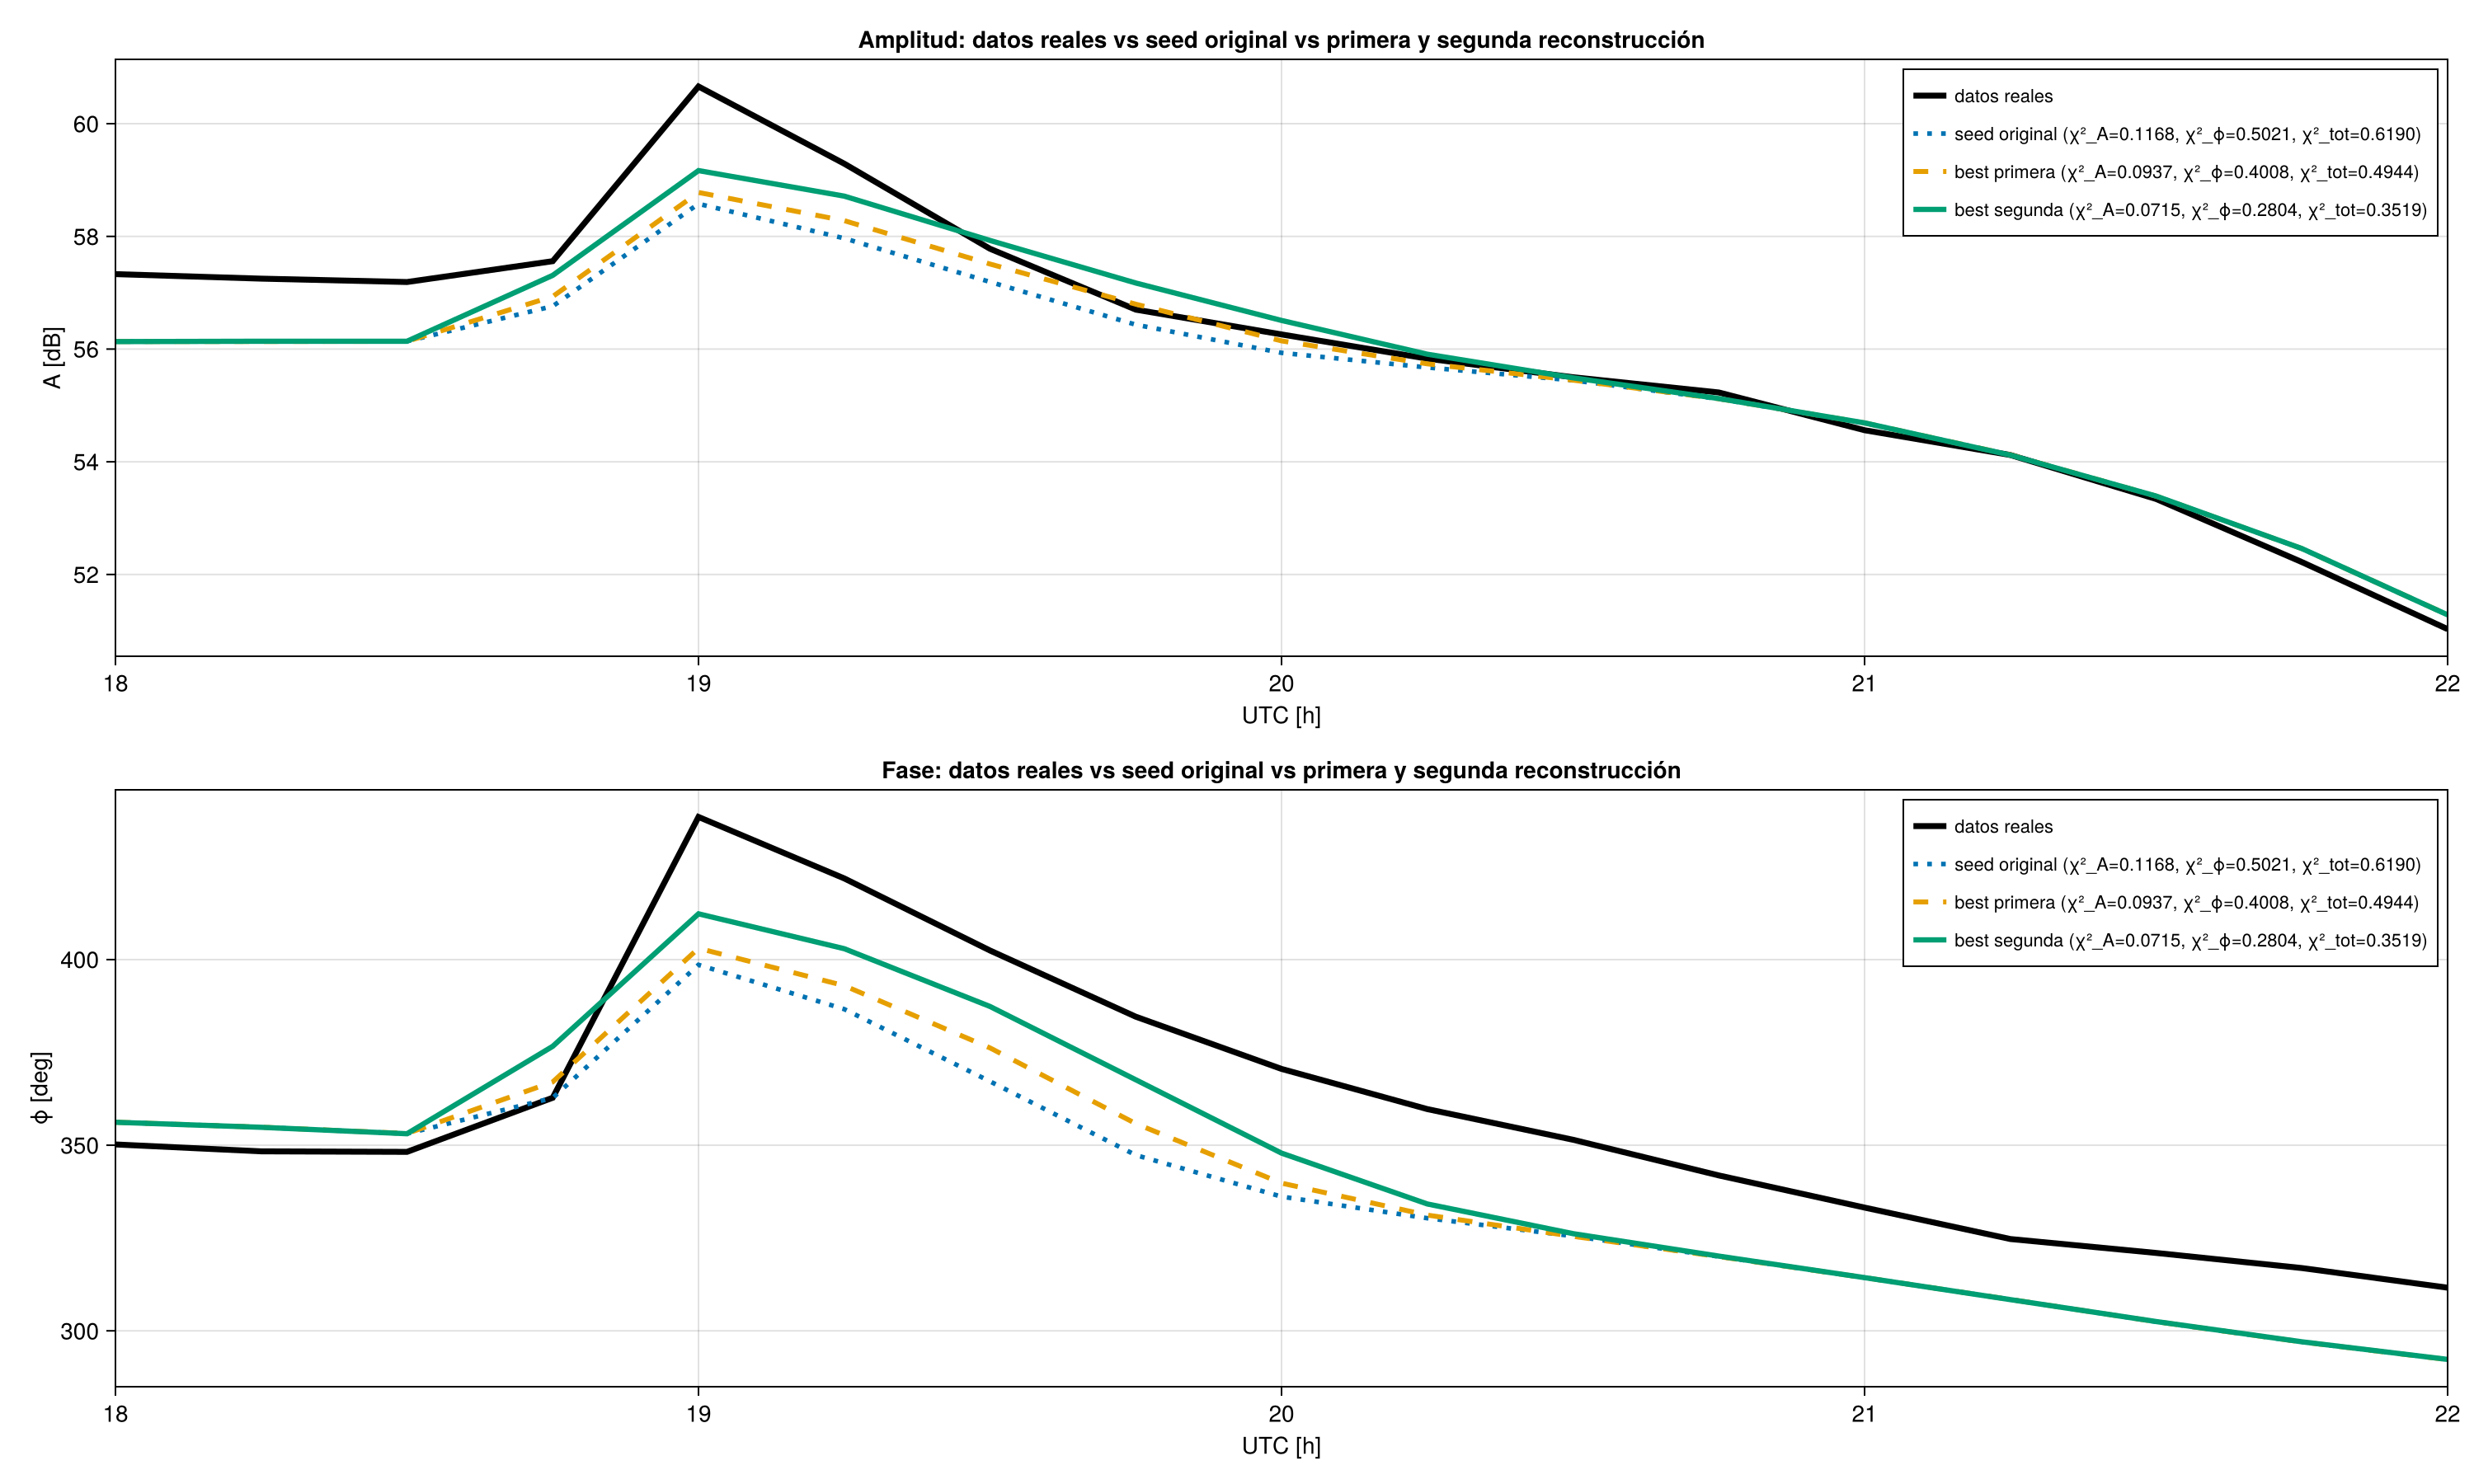

In [17]:

# ============================================================
# Figura 1: datos reales vs seed original vs best1 vs best2
# ============================================================

fig = CM.Figure(size = (1500, 900))

axA = CM.Axis(
    fig[1, 1],
    title = "Amplitud: datos reales vs seed original vs primera y segunda reconstrucción",
    xlabel = "UTC [h]",
    ylabel = "A [dB]",
)

axP = CM.Axis(
    fig[2, 1],
    title = "Fase: datos reales vs seed original vs primera y segunda reconstrucción",
    xlabel = "UTC [h]",
    ylabel = "ϕ [deg]",
)

label_seed0 = label_metrics("seed original", m_seed0)
label_best1 = label_metrics("best primera", m_best1)
label_best2 = label_metrics("best segunda", m_best2)

CM.lines!(axA, t_hours, target_A_corr, color = :black, linewidth = 3.6, label = "datos reales")
CM.lines!(axA, t_hours, A_seed_0, linestyle = :dot, linewidth = 2.8, label = label_seed0)
CM.lines!(axA, t_hours, A_best_1, linestyle = :dash, linewidth = 3.0, label = label_best1)
CM.lines!(axA, t_hours, A_best_2, linewidth = 3.2, label = label_best2)

CM.lines!(axP, t_hours, target_phi_corr, color = :black, linewidth = 3.6, label = "datos reales")
CM.lines!(axP, t_hours, phi_seed_0, linestyle = :dot, linewidth = 2.8, label = label_seed0)
CM.lines!(axP, t_hours, phi_best_1, linestyle = :dash, linewidth = 3.0, label = label_best1)
CM.lines!(axP, t_hours, phi_best_2, linewidth = 3.2, label = label_best2)

for ax in [axA, axP]
    CM.xlims!(ax, 18, 22)
    ax.xticks = 18:1:22
end

CM.axislegend(axA, position = :rt, labelsize = 11, framevisible = true)
CM.axislegend(axP, position = :rt, labelsize = 11, framevisible = true)

CM.save(joinpath(FIG_DIR, "01_series_datos_seed0_best1_best2.png"), fig, px_per_unit = 2)
fig


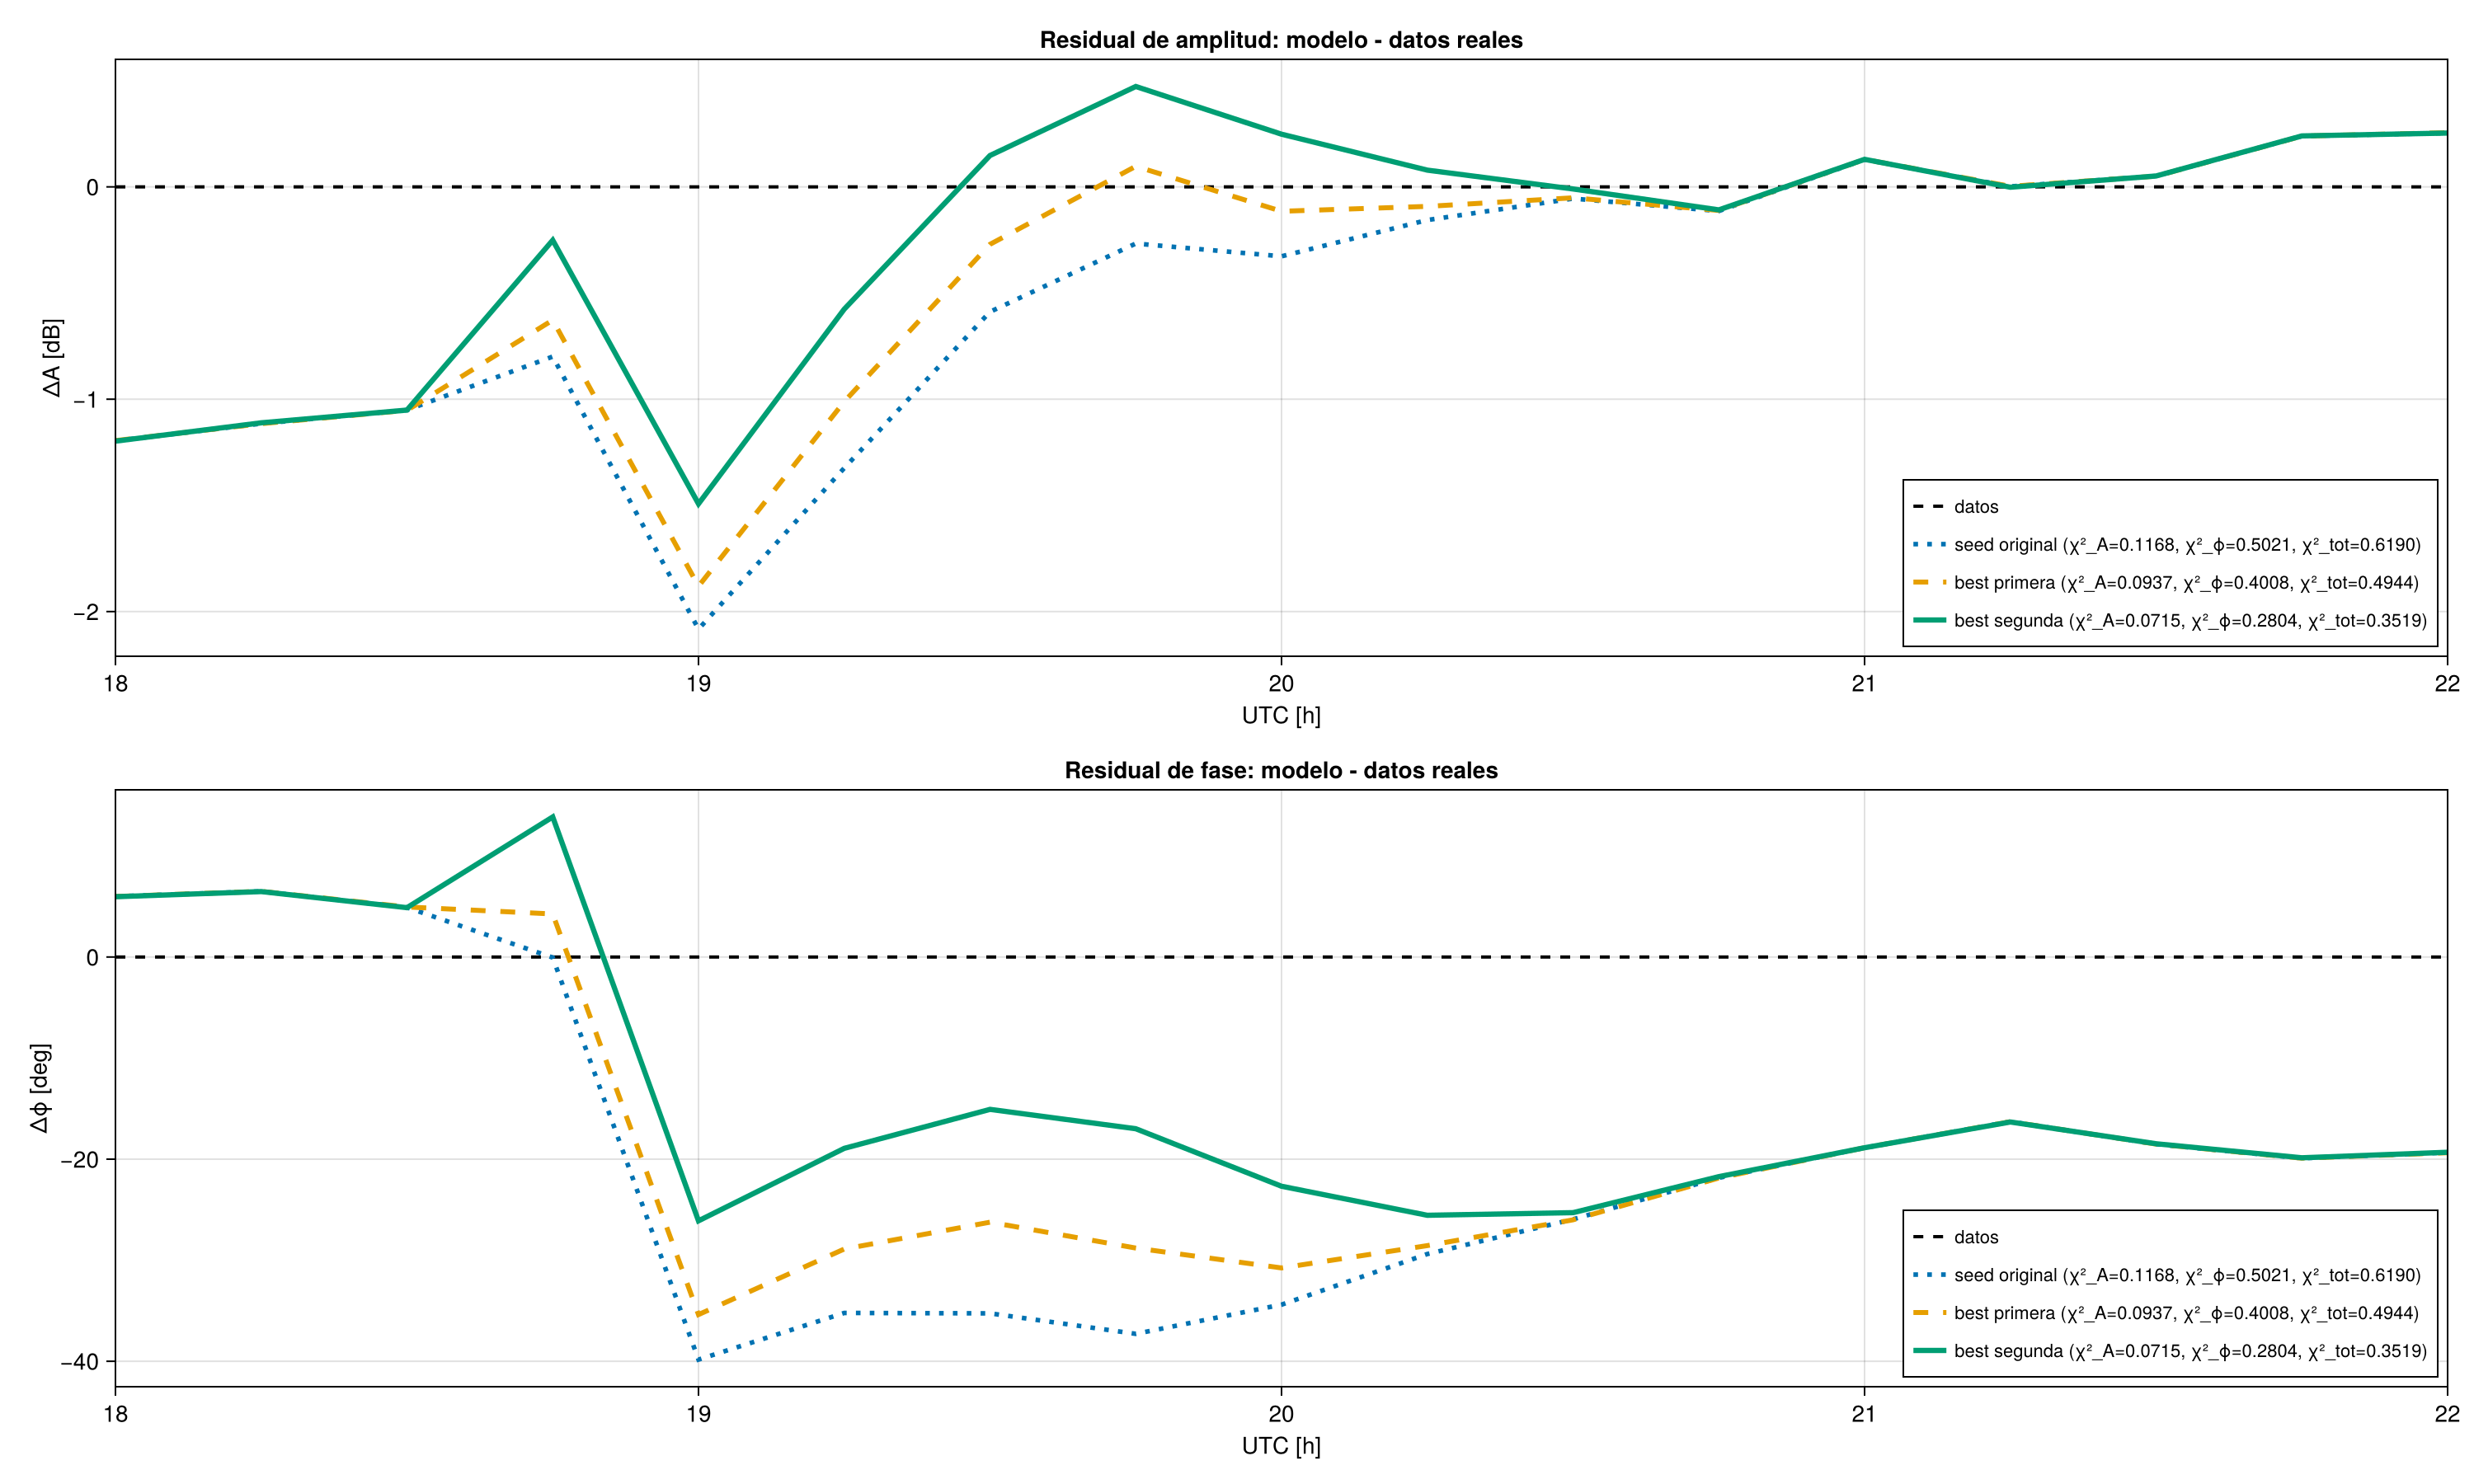

In [13]:

# ============================================================
# Figura 2: residuales modelo - datos reales
# ============================================================

resA_seed0 = A_seed_0 .- target_A_corr
resA_best1 = A_best_1 .- target_A_corr
resA_best2 = A_best_2 .- target_A_corr

resP_seed0 = phi_seed_0 .- target_phi_corr
resP_best1 = phi_best_1 .- target_phi_corr
resP_best2 = phi_best_2 .- target_phi_corr

fig = CM.Figure(size = (1500, 900))

axA = CM.Axis(
    fig[1, 1],
    title = "Residual de amplitud: modelo - datos reales",
    xlabel = "UTC [h]",
    ylabel = "ΔA [dB]",
)

axP = CM.Axis(
    fig[2, 1],
    title = "Residual de fase: modelo - datos reales",
    xlabel = "UTC [h]",
    ylabel = "Δϕ [deg]",
)

CM.hlines!(axA, [0.0], color = :black, linewidth = 2.0, linestyle = :dash, label = "datos")
CM.lines!(axA, t_hours, resA_seed0, linestyle = :dot, linewidth = 2.8, label = label_seed0)
CM.lines!(axA, t_hours, resA_best1, linestyle = :dash, linewidth = 3.0, label = label_best1)
CM.lines!(axA, t_hours, resA_best2, linewidth = 3.2, label = label_best2)

CM.hlines!(axP, [0.0], color = :black, linewidth = 2.0, linestyle = :dash, label = "datos")
CM.lines!(axP, t_hours, resP_seed0, linestyle = :dot, linewidth = 2.8, label = label_seed0)
CM.lines!(axP, t_hours, resP_best1, linestyle = :dash, linewidth = 3.0, label = label_best1)
CM.lines!(axP, t_hours, resP_best2, linewidth = 3.2, label = label_best2)

for ax in [axA, axP]
    CM.xlims!(ax, 18, 22)
    ax.xticks = 18:1:22
end

CM.axislegend(axA, position = :rb, labelsize = 11, framevisible = true)
CM.axislegend(axP, position = :rb, labelsize = 11, framevisible = true)

CM.save(joinpath(FIG_DIR, "02_residuales_seed0_best1_best2.png"), fig, px_per_unit = 2)
fig


In [14]:

# ============================================================
# Tabla de puntos clave 18, 19, 20, 21, 22 UTC
# ============================================================

wanted_hours = [18.0, 19.0, 20.0, 21.0, 22.0]
idxs = [argmin(abs.(t_hours .- h)) for h in wanted_hours]

points_df = DataFrame(
    UTC = t_hours[idxs],

    A_data = target_A_corr[idxs],
    A_seed0 = A_seed_0[idxs],
    A_best1 = A_best_1[idxs],
    A_best2 = A_best_2[idxs],
    resA_seed0 = resA_seed0[idxs],
    resA_best1 = resA_best1[idxs],
    resA_best2 = resA_best2[idxs],

    phi_data = target_phi_corr[idxs],
    phi_seed0 = phi_seed_0[idxs],
    phi_best1 = phi_best_1[idxs],
    phi_best2 = phi_best_2[idxs],
    resphi_seed0 = resP_seed0[idxs],
    resphi_best1 = resP_best1[idxs],
    resphi_best2 = resP_best2[idxs],
)

display(points_df)


Row,UTC,A_data,A_seed0,A_best1,A_best2,resA_seed0,resA_best1,resA_best2,phi_data,phi_seed0,phi_best1,phi_best2,resphi_seed0,resphi_best1,resphi_best2
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,18.0,57.33,56.134,56.1352,56.1326,-1.19601,-1.19483,-1.19739,350.2,356.202,356.191,356.168,6.00213,5.99053,5.96792
2,19.0,60.66,58.5773,58.7793,59.1674,-2.08267,-1.8807,-1.49256,438.42,398.587,403.04,412.317,-39.8327,-35.3804,-26.1025
3,20.0,56.26,55.933,56.1451,56.508,-0.327008,-0.114898,0.247991,370.54,336.142,339.776,347.857,-34.3977,-30.7637,-22.6827
4,21.0,54.56,54.6884,54.6893,54.6896,0.128401,0.129325,0.129601,333.19,314.314,314.321,314.32,-18.8764,-18.8692,-18.8701
5,22.0,51.03,51.2834,51.2852,51.2834,0.25341,0.25522,0.253378,311.61,292.268,292.244,292.291,-19.3424,-19.3658,-19.3186


Row,parametro,seed_original,best_primera,best_segunda,ratio_best1_seed0,ratio_best2_seed0,ratio_best2_best1
,SubStrin…,Float64,Float64,Float64,Float64,Float64,Float64
1,amp,20.0,20.0732,20.5459,1.00366,1.02729,1.02355
2,t_pk_s,1609.47,1626.68,1605.79,1.01069,0.997715,0.987162
3,tau_u_s,190.578,209.338,205.004,1.09843,1.07569,0.979298
4,tau_d_s,1248.56,1444.71,1659.41,1.1571,1.32906,1.14862
5,eps_s,789.685,767.344,760.45,0.971708,0.962979,0.991016
6,z0_km,85.0,84.3975,83.0268,0.992912,0.976786,0.983758
7,hz_km,10.0,10.3638,11.0436,1.03638,1.10436,1.06559


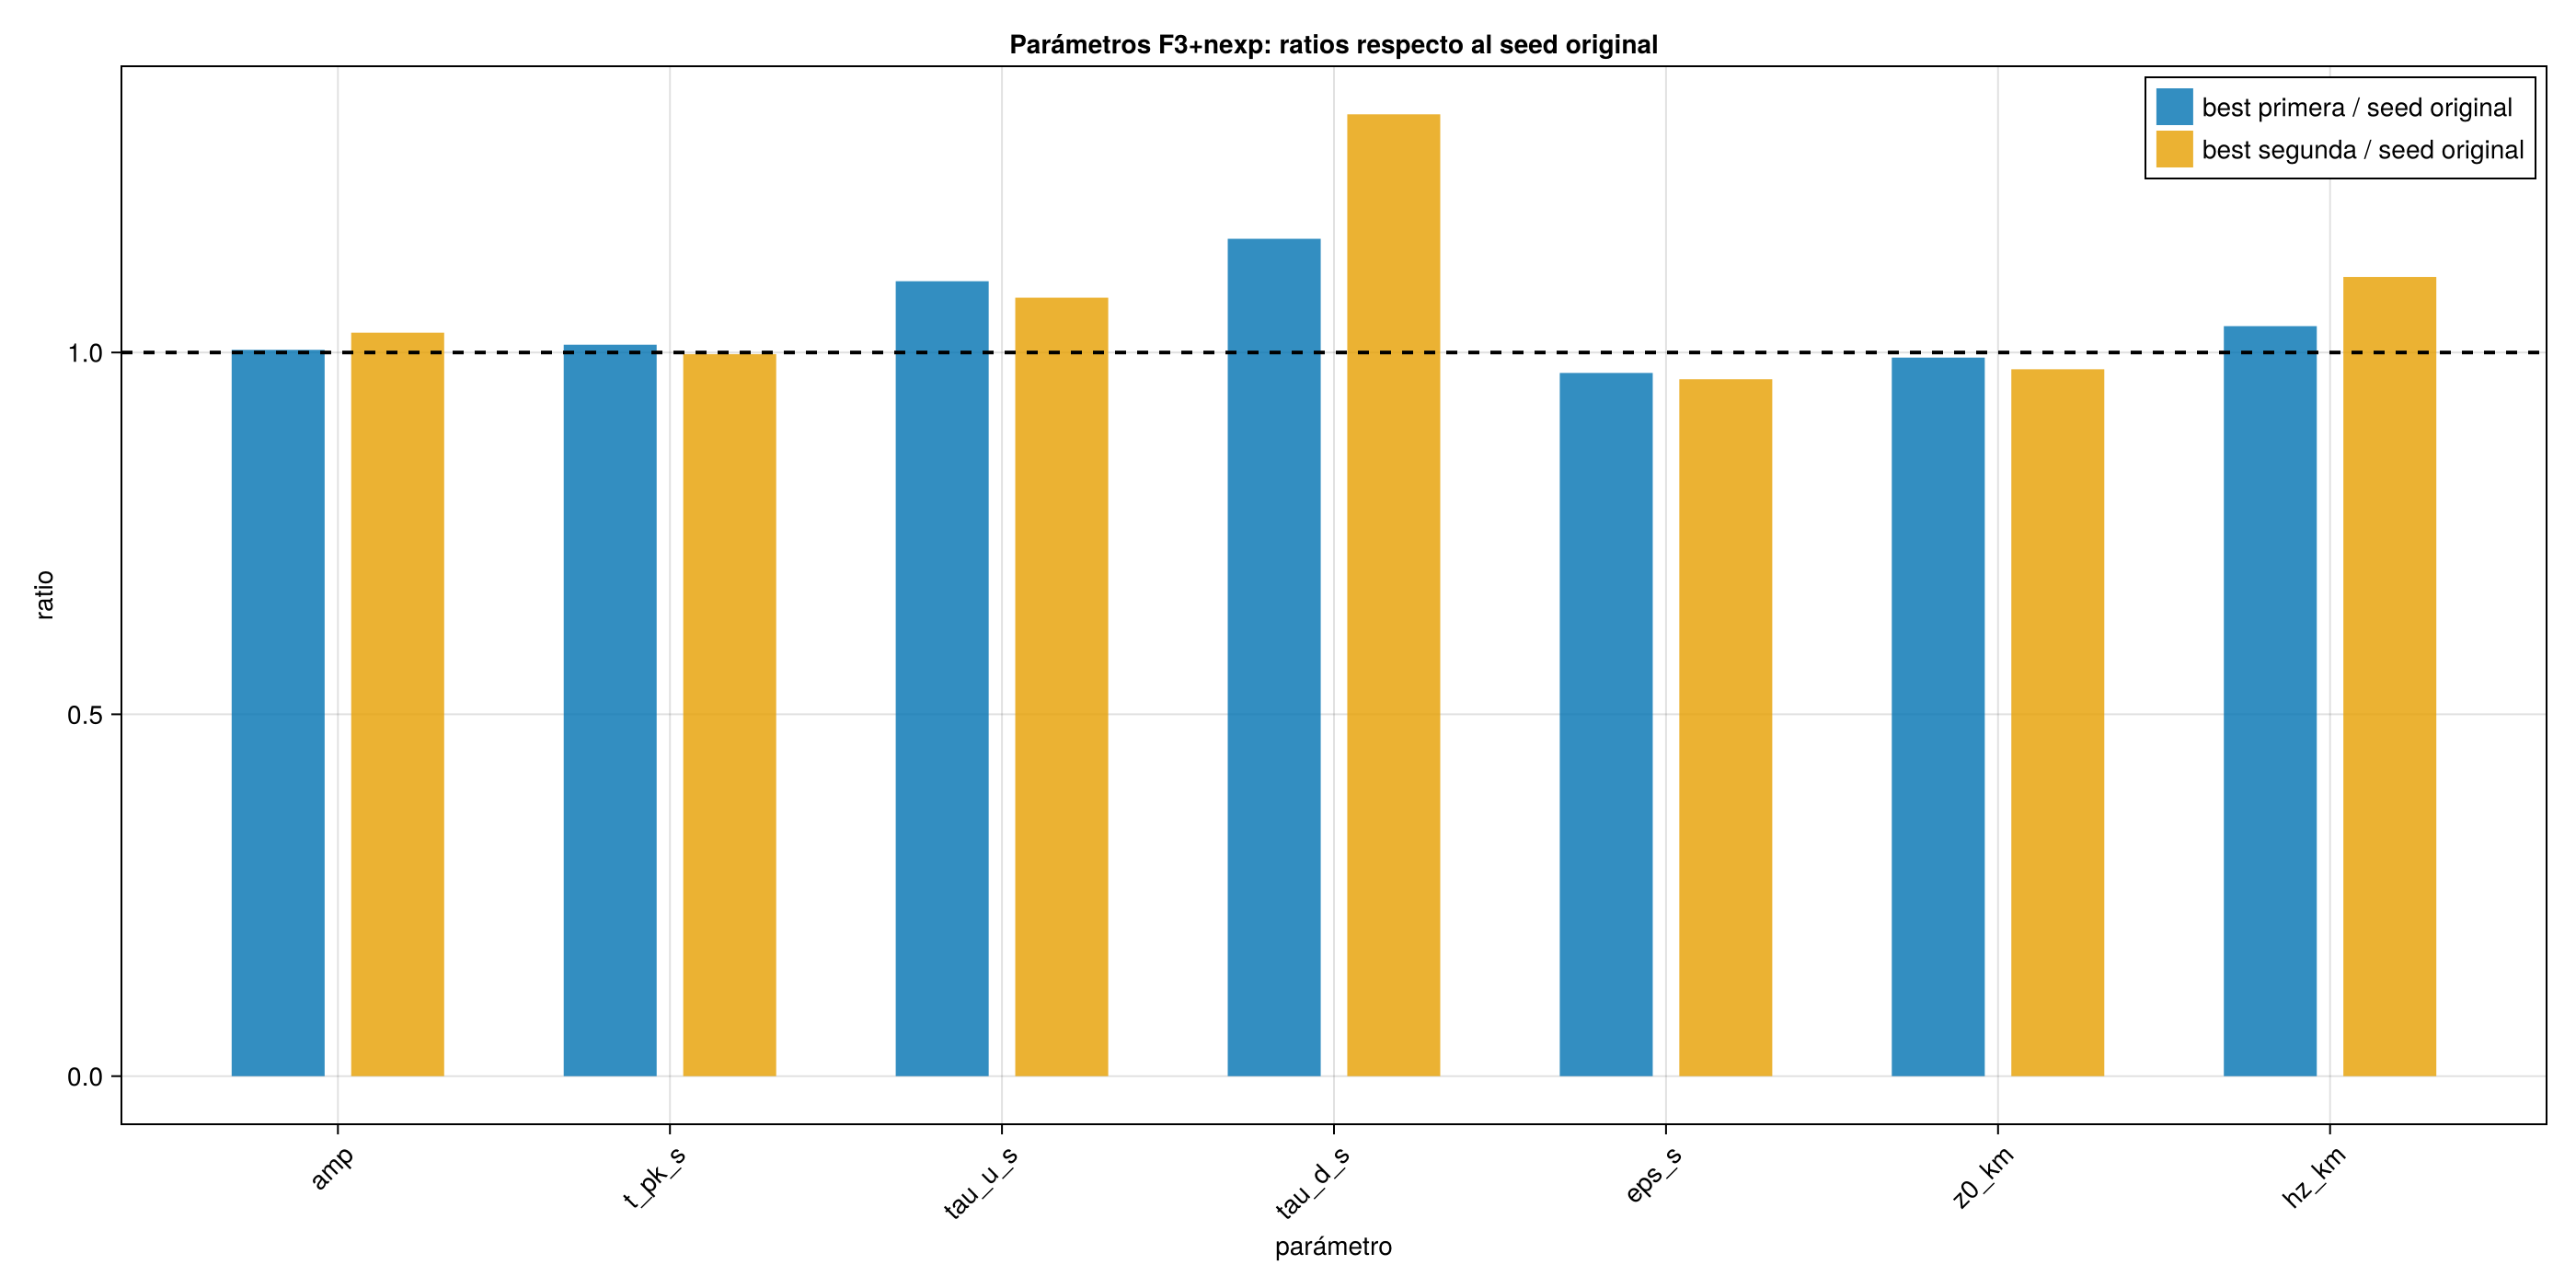

In [15]:

# ============================================================
# Figura 3: parámetros F3+nexp
# ============================================================

param_names = split(attr_string(SECOND_H5, "parameter_names"; default="amp,t_pk_s,tau_u_s,tau_d_s,eps_s,z0_km,hz_km"), ",")

param_df = DataFrame(
    parametro = param_names,
    seed_original = initial_params_1,
    best_primera = best_params_1,
    best_segunda = best_params_2,
    ratio_best1_seed0 = best_params_1 ./ initial_params_1,
    ratio_best2_seed0 = best_params_2 ./ initial_params_1,
    ratio_best2_best1 = best_params_2 ./ best_params_1,
)

display(param_df)

fig = CM.Figure(size = (1400, 700))
ax = CM.Axis(
    fig[1, 1],
    title = "Parámetros F3+nexp: ratios respecto al seed original",
    xlabel = "parámetro",
    ylabel = "ratio",
    xticklabelrotation = π/4,
)

x = 1:length(param_names)
CM.barplot!(ax, x .- 0.18, param_df.ratio_best1_seed0, width = 0.35, label = "best primera / seed original")
CM.barplot!(ax, x .+ 0.18, param_df.ratio_best2_seed0, width = 0.35, label = "best segunda / seed original")
CM.hlines!(ax, [1.0], color = :black, linestyle = :dash, linewidth = 2)
ax.xticks = (x, param_names)
CM.axislegend(ax, position = :rt)

CM.save(joinpath(FIG_DIR, "03_parametros_F3_ratios.png"), fig, px_per_unit = 2)
fig


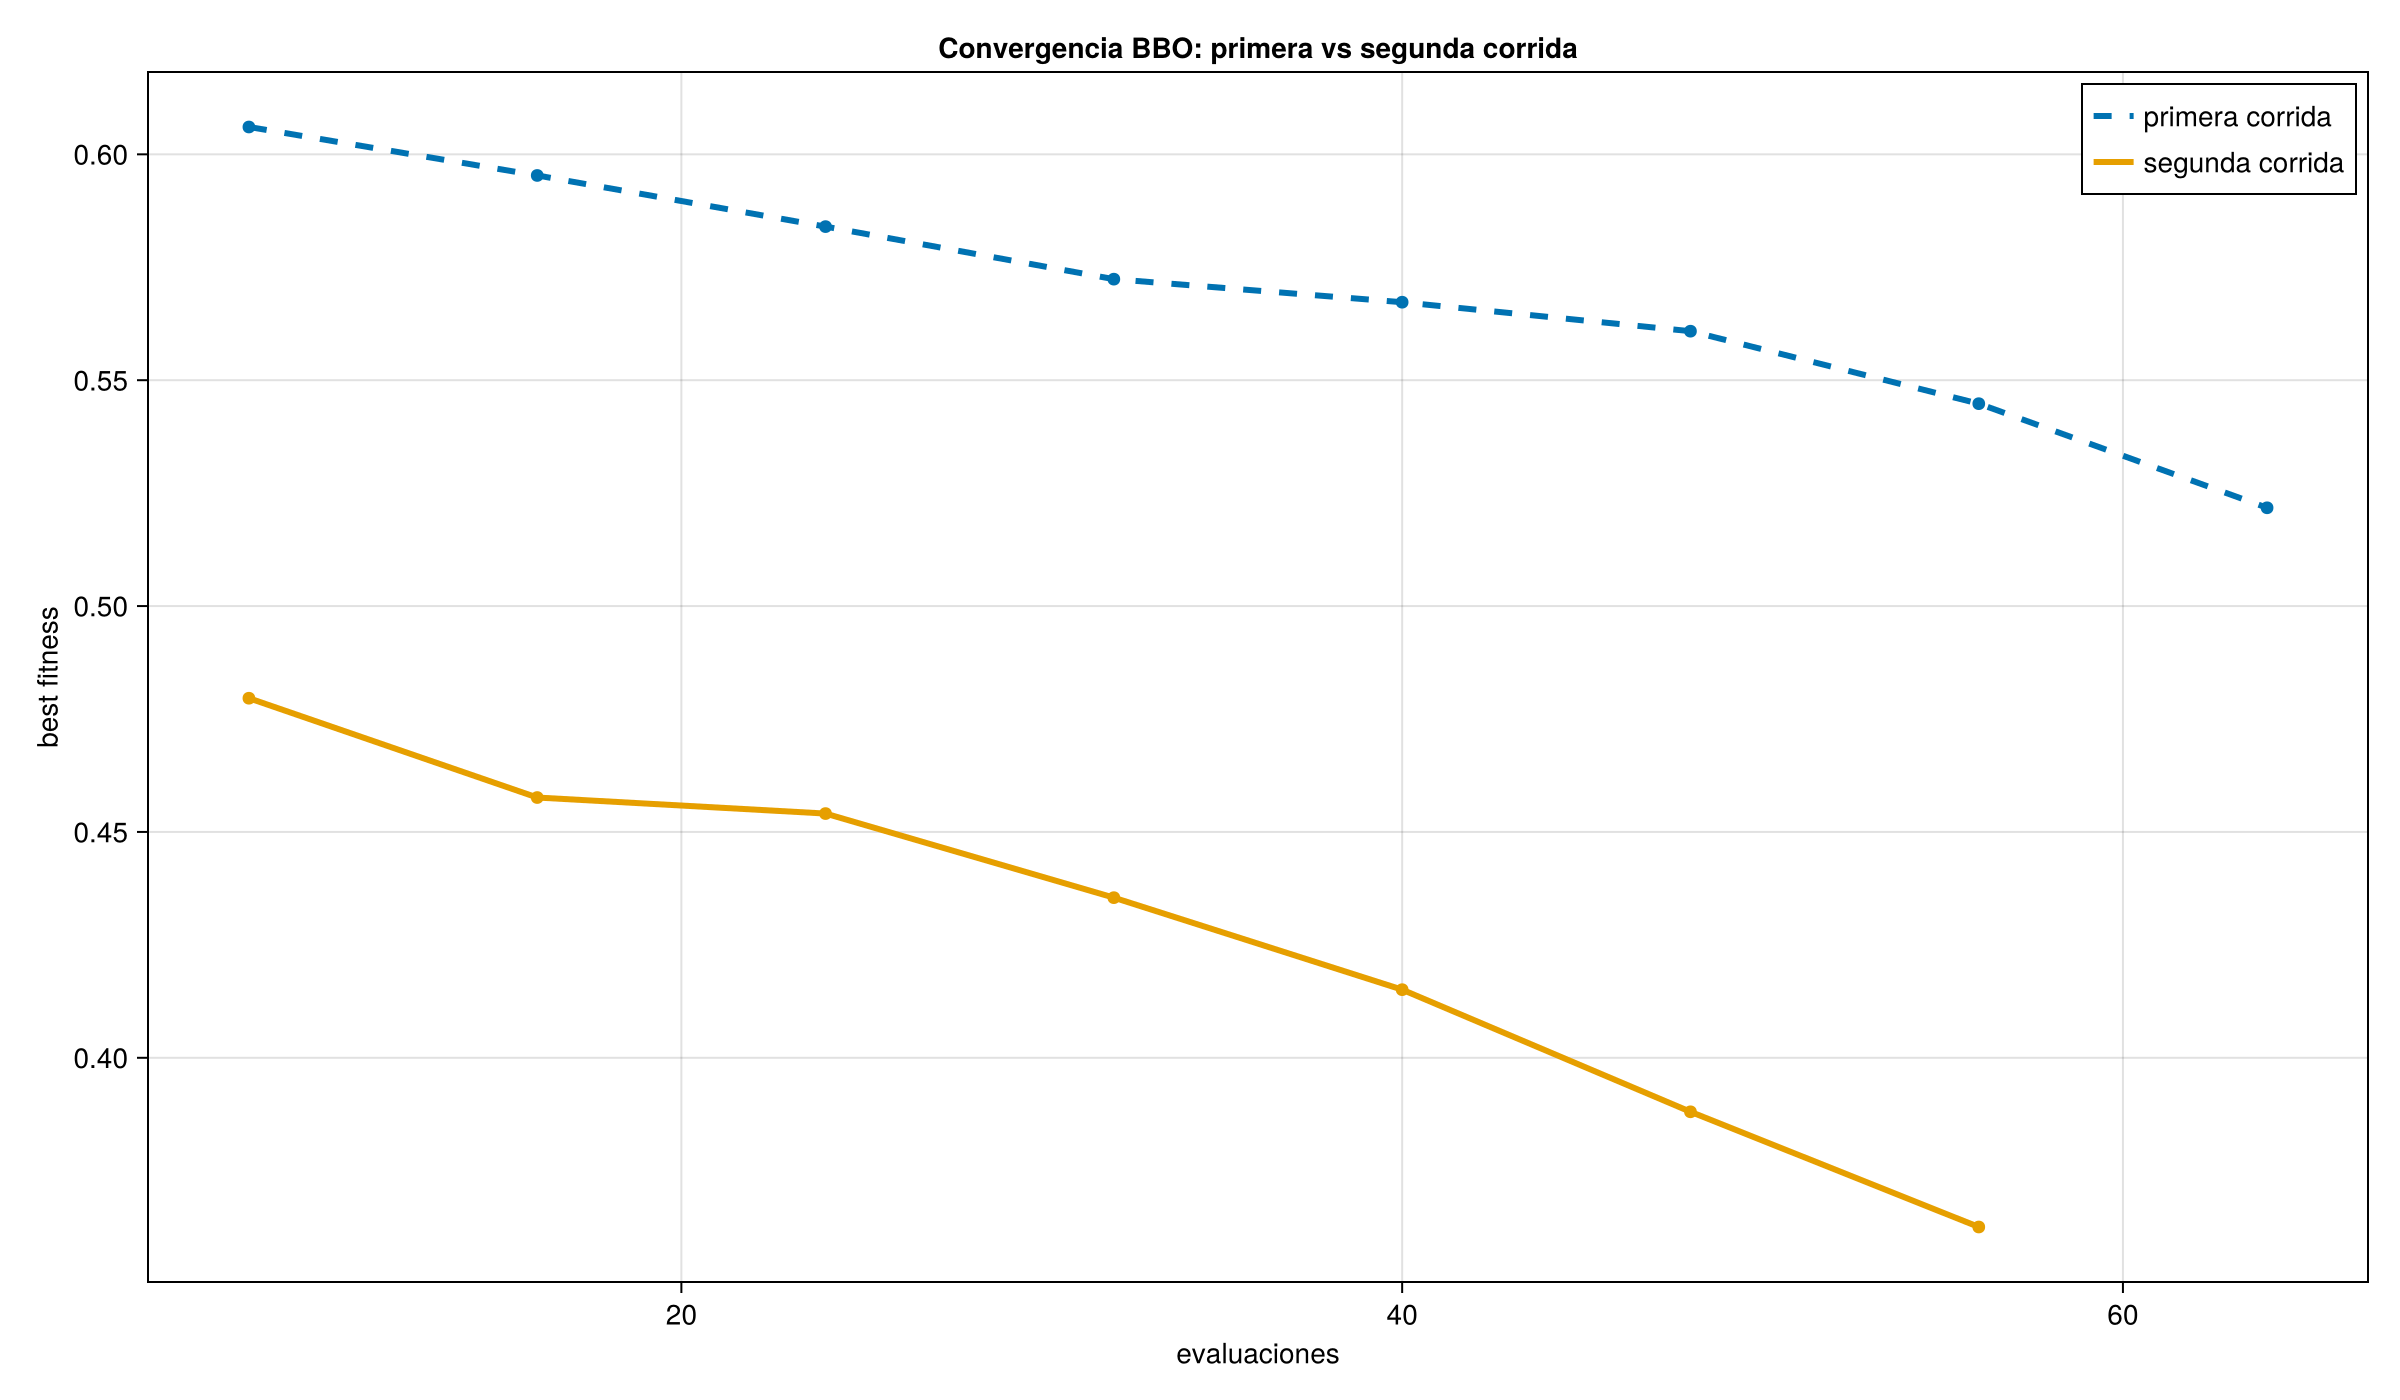

In [16]:

# ============================================================
# Figura 4: convergencia BBO de ambas corridas
# ============================================================

function read_convergence_from_out(path)
    secs = Float64[]
    evals = Int[]
    fitness = Float64[]

    if !isfile(path)
        return secs, evals, fitness
    end

    for line in eachline(path)
        m = match(r"^\s*([0-9.]+)\s+secs,\s+(\d+)\s+evals.*fitness=([0-9.eE+\-]+)", line)
        if m !== nothing
            push!(secs, parse(Float64, m.captures[1]))
            push!(evals, parse(Int, m.captures[2]))
            push!(fitness, parse(Float64, m.captures[3]))
        end
    end

    return secs, evals, fitness
end

secs1, evals1, fit1 = read_convergence_from_out(FIRST_OUT)
secs2, evals2, fit2 = read_convergence_from_out(SECOND_OUT)

if isempty(fit1) && isempty(fit2)
    println("No encontré historial de fitness en los .out.")
else
    fig = CM.Figure(size = (1200, 700))
    ax = CM.Axis(
        fig[1, 1],
        title = "Convergencia BBO: primera vs segunda corrida",
        xlabel = "evaluaciones",
        ylabel = "best fitness",
    )

    if !isempty(fit1)
        CM.lines!(ax, evals1, fit1, linewidth = 3, linestyle = :dash, label = "primera corrida")
        CM.scatter!(ax, evals1, fit1, markersize = 9)
    end

    if !isempty(fit2)
        CM.lines!(ax, evals2, fit2, linewidth = 3, label = "segunda corrida")
        CM.scatter!(ax, evals2, fit2, markersize = 9)
    end

    CM.axislegend(ax, position = :rt)
    CM.save(joinpath(FIG_DIR, "04_convergencia_primera_segunda.png"), fig, px_per_unit = 2)
    fig
end



## Lectura esperada

La comparación principal es:

```text
seed original de la primera corrida  →  best primera corrida  →  best segunda corrida
```

La segunda corrida debe interpretarse como un restart real si:

```text
best_params_1 == initial_params_2
```

y si las series `A_best_1, phi_best_1` coinciden con `A_seed_2, phi_seed_2` salvo pequeñas diferencias numéricas de reevaluación.

Las métricas relevantes son las calculadas desde las series de tiempo contra el mismo target corregido, no líneas sueltas del `.out`.


SOURCE_SCRIPT_FIRST = new-perturbation-data-inversion-bbo_F3_nexp_fixed_CLEAN_v3_oldASLS_BG_from_H5.jl
BACKGROUND_H5       = new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
RUN1_H5             = new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_results_14760926.h5
RUN2_H5             = new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_seed_from_14760926_results_15175350.h5
RUN3_H5             = new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_seed_from_15175350_results_15298436.h5
DATA_H5             = datos_asls_full-v3.h5

Llaves usadas:
  seed0 : initial_params
  best1 : reco_params
  best2 : reco_params
  best3 : reco_params

Continuidad paramétrica:
  max |best1 - seed2| = 0.000000e+00
  max |best2 - seed3| = 0.000000e+00

Grilla temporal:
  length(zdt_plot) = 49
  primero = 2008-03-25T18:00:00+00:00
  último  = 2008-03-25T22:00:00+00:00

Target 5 min:
  length(target_A_plot)   = 49
  length(target_phi_plot) = 49
  A range   = 57.330 → 51.0

Row,curva,chi2_A,chi2_phi,chi2_total,rmse_A_dB,rmse_phi_deg
,String,Float64,Float64,Float64,Float64,Float64
1,seed FIRI/F3,0.126685,0.496969,0.623654,0.834596,25.0324
2,best batch 1,0.101484,0.391786,0.49327,0.746986,22.2261
3,best batch 2,0.0749796,0.264595,0.339574,0.642074,18.2654
4,best batch 3,0.0770018,0.195096,0.272098,0.650675,15.6842



Curvas 5 min guardadas en: perturbacion_F3_oldASLS_seed0_best1_best2_best3_5min_curves.h5


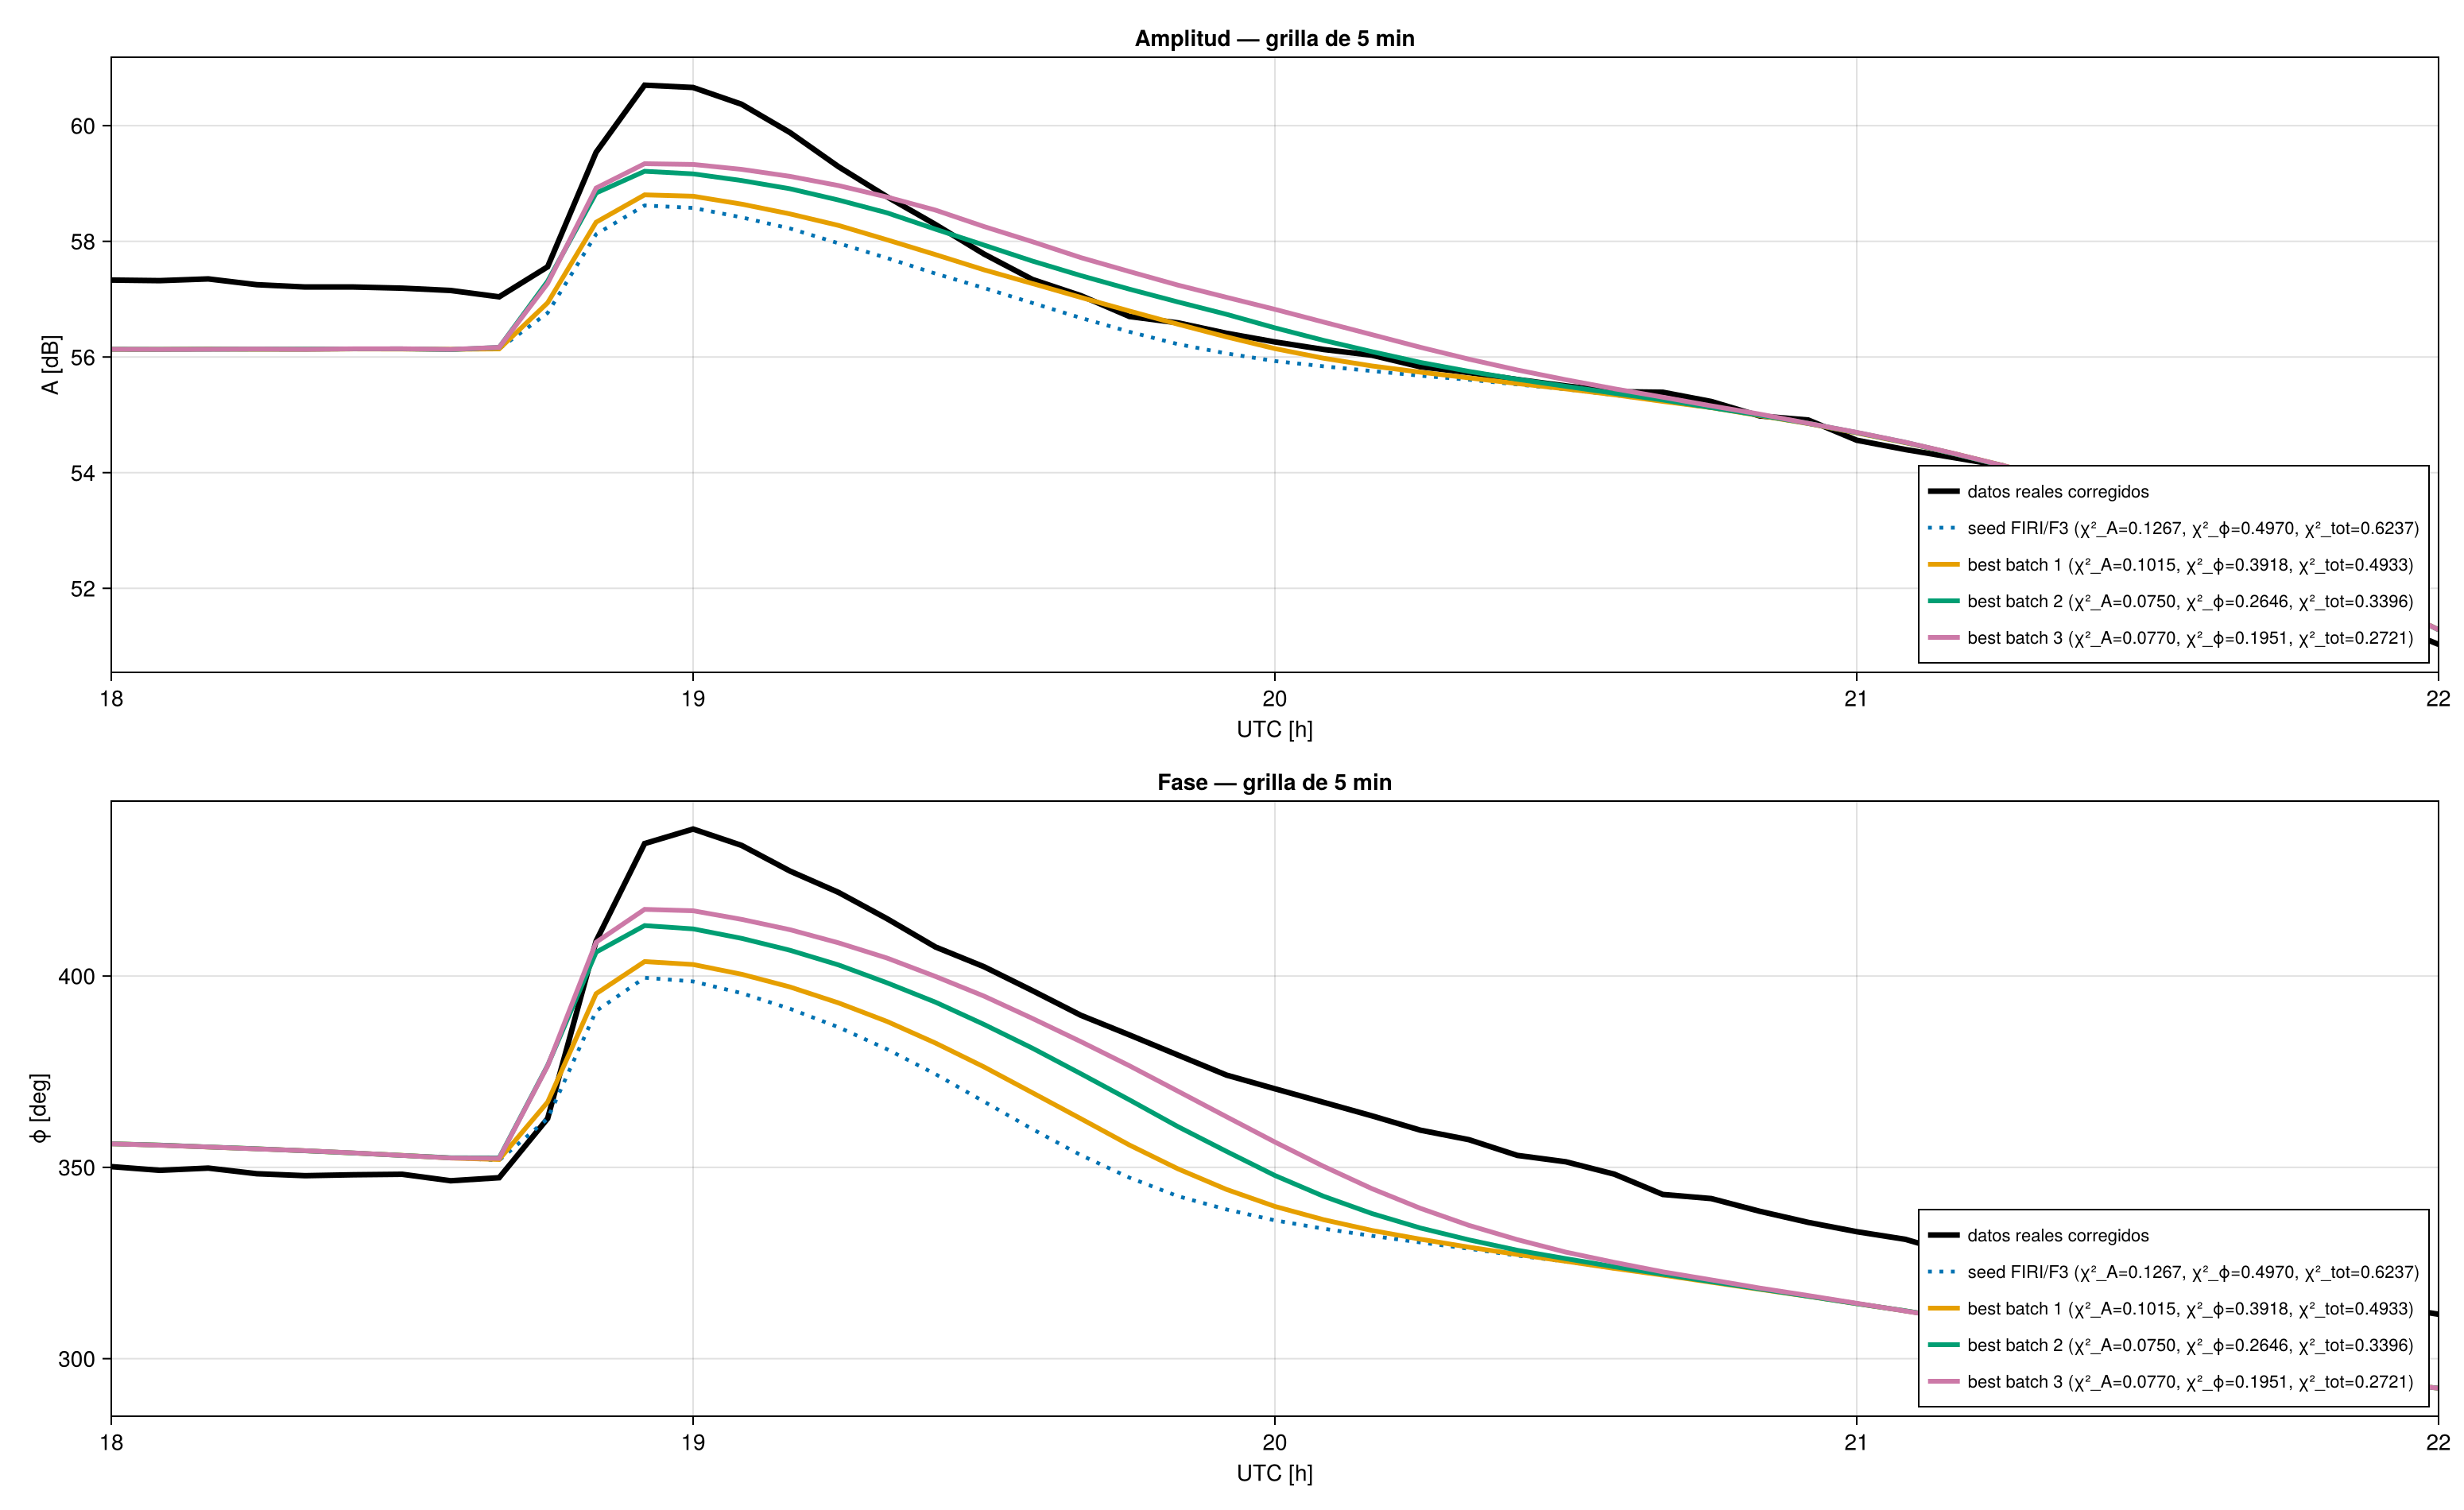

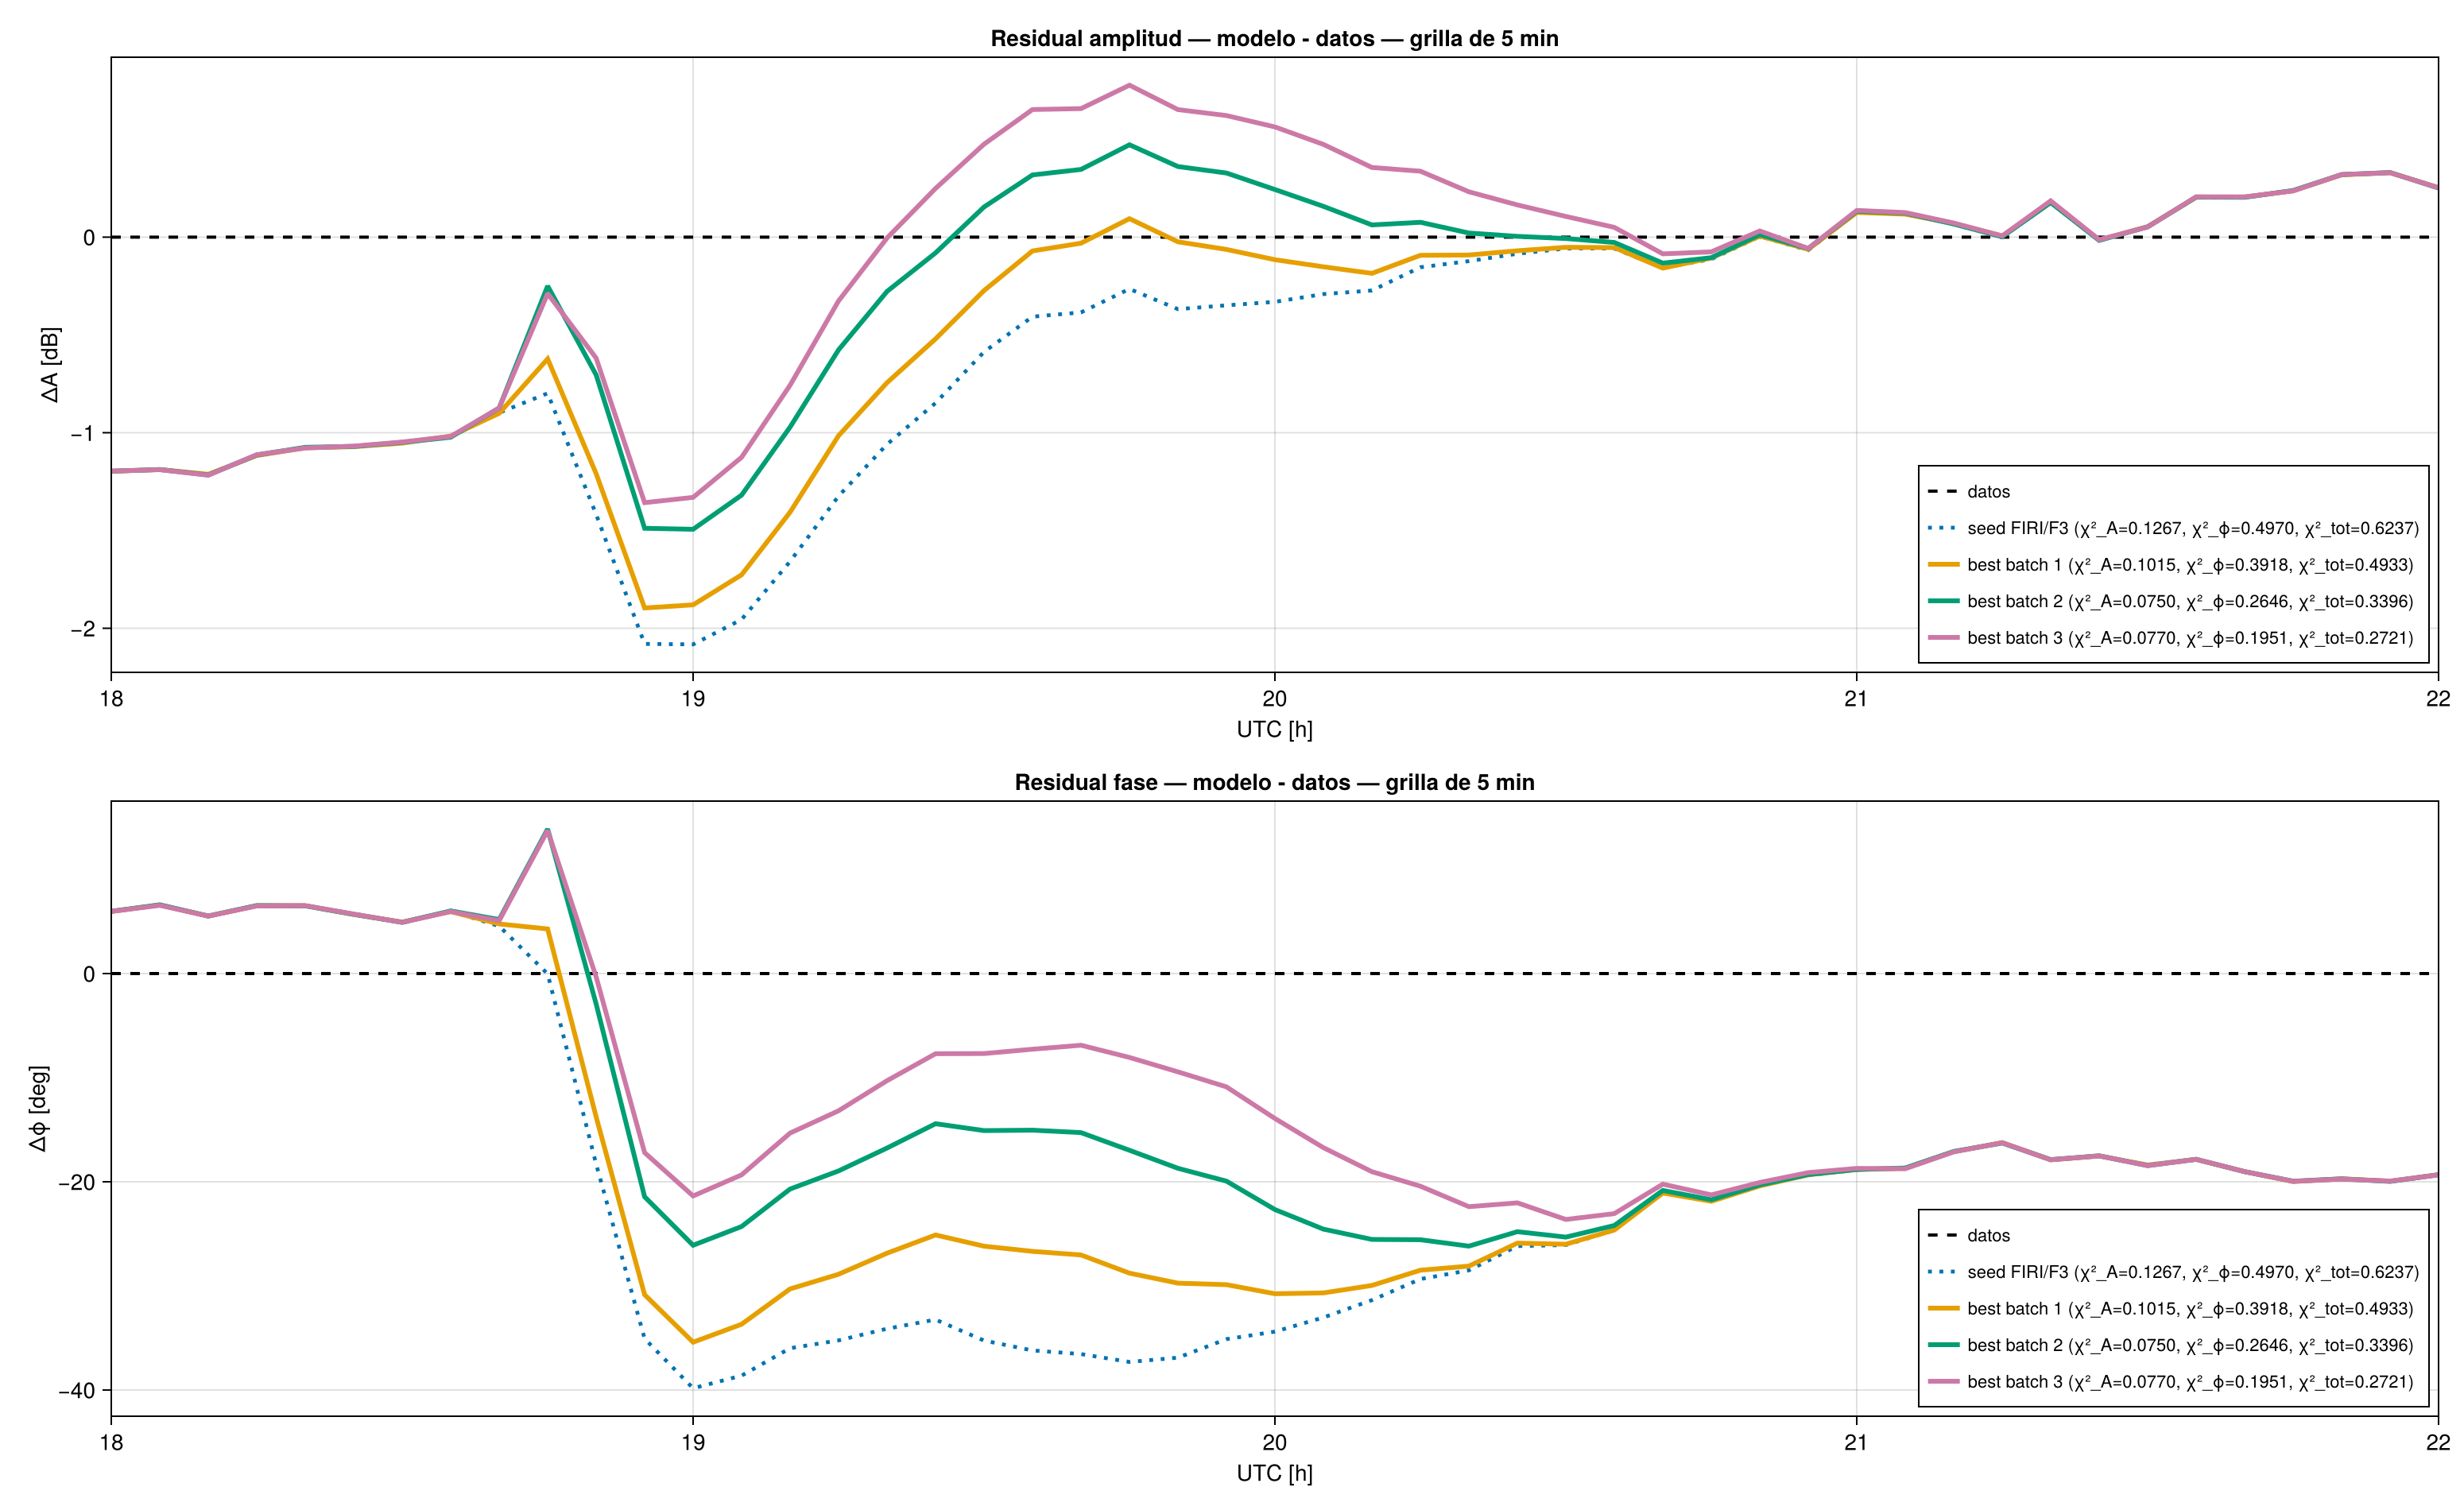

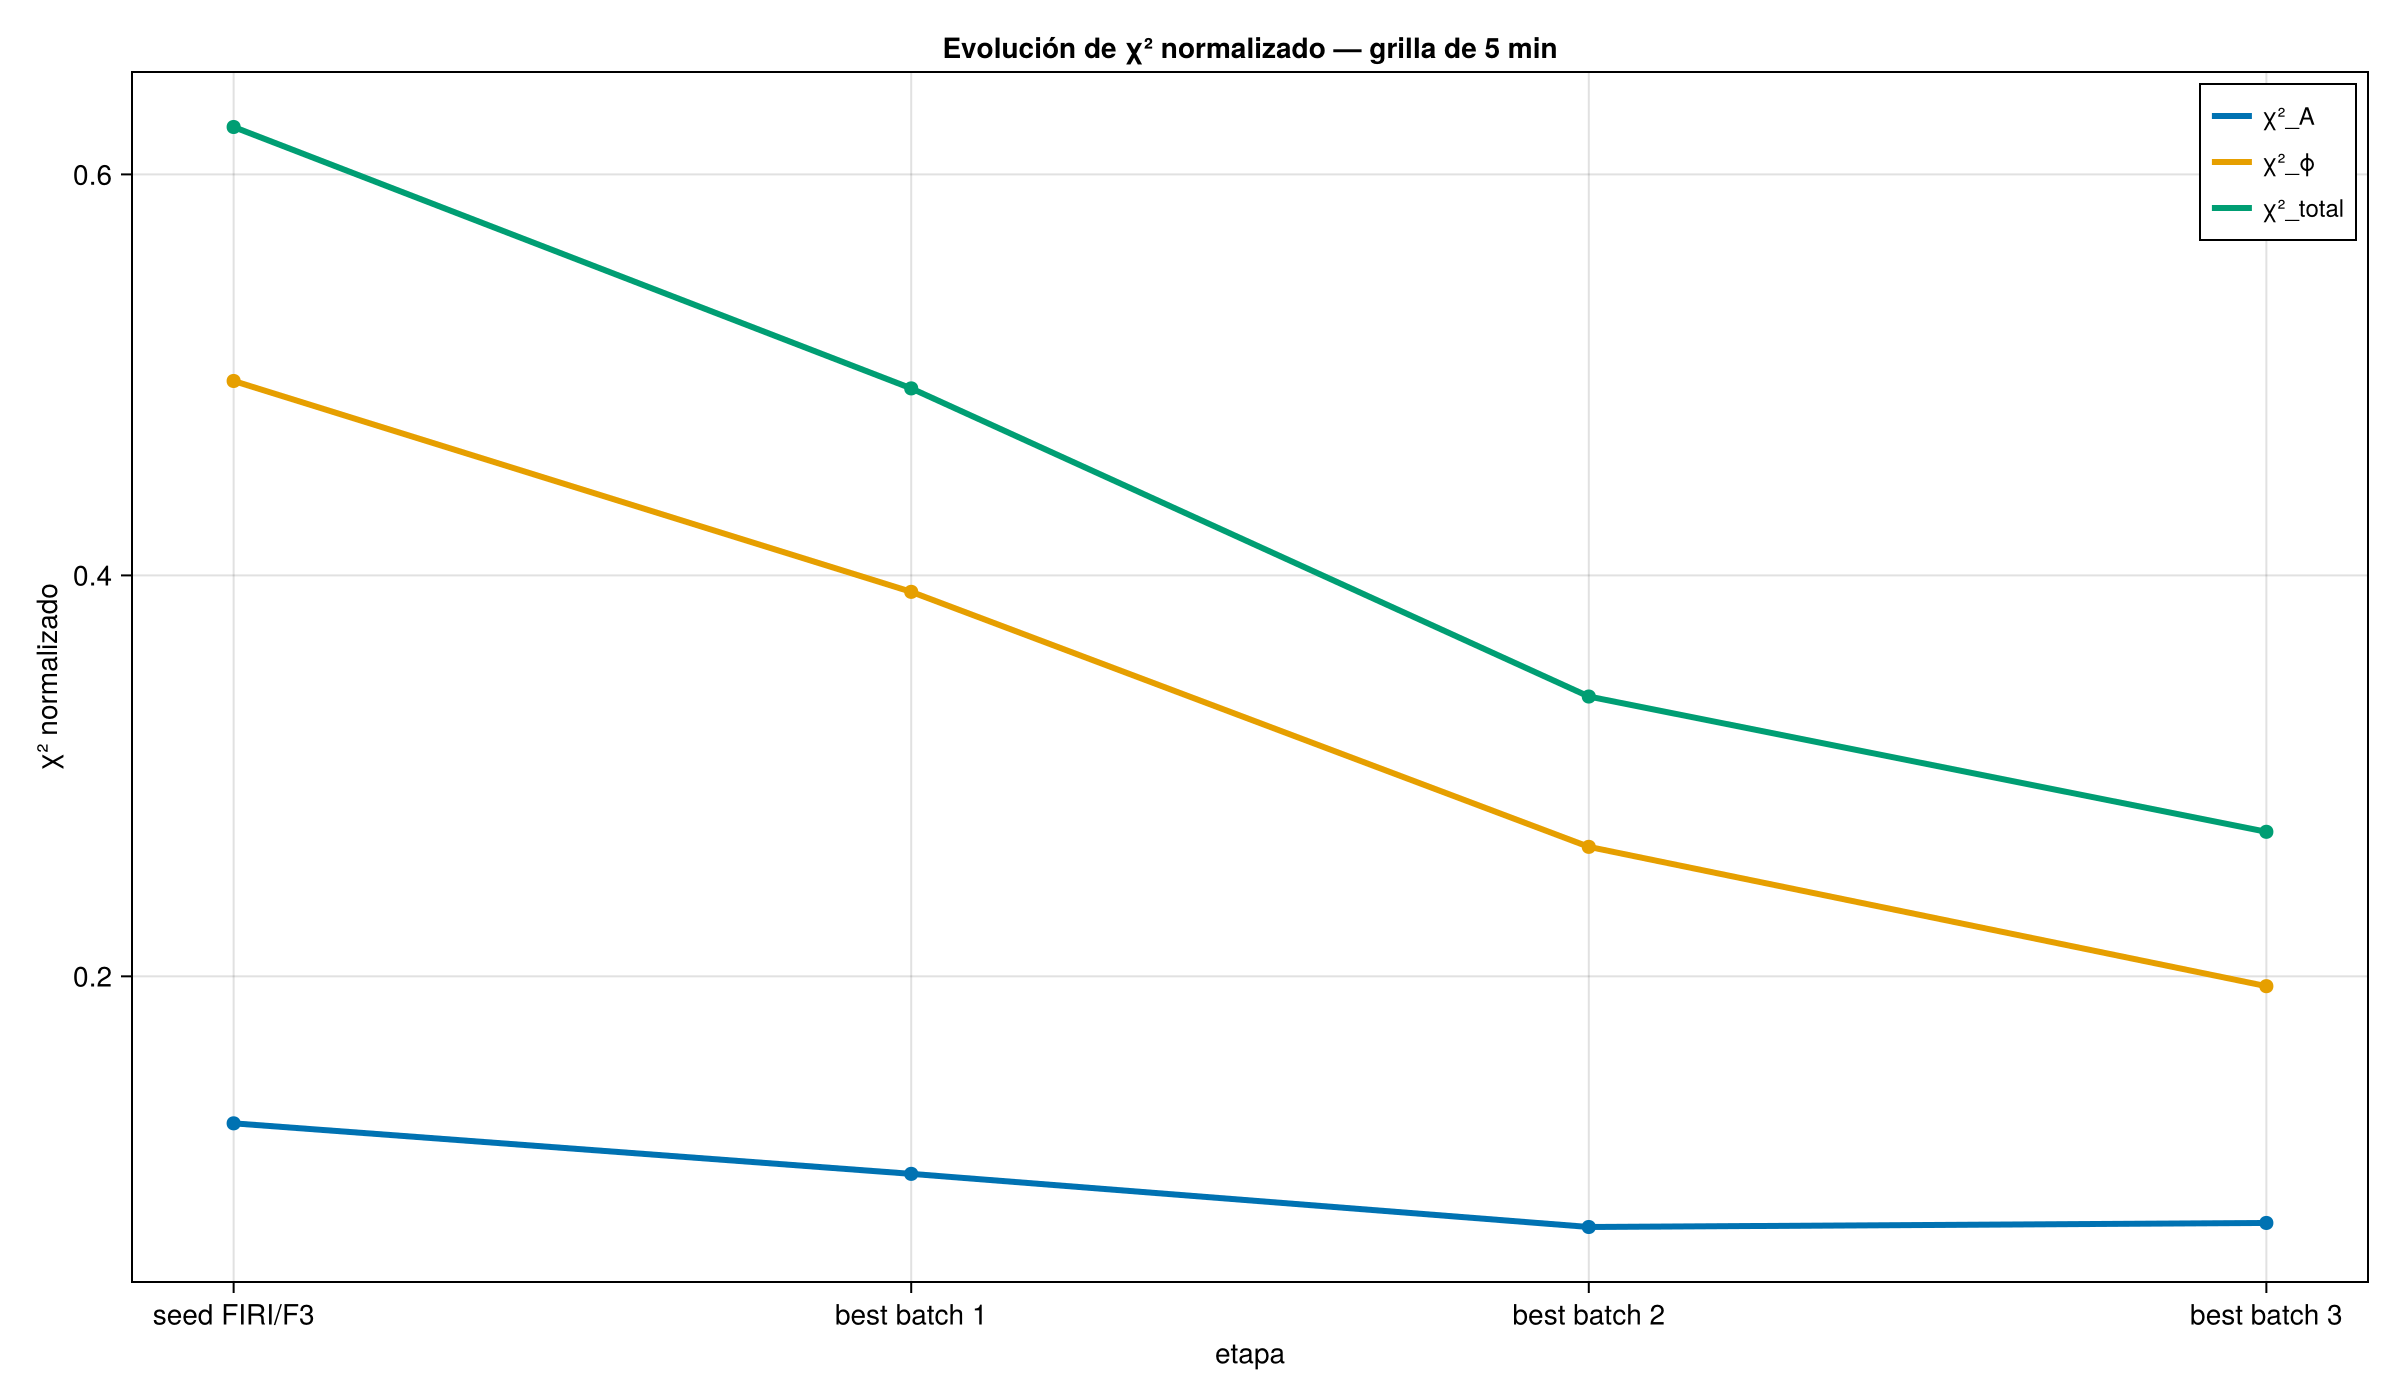

CairoMakie.Screen{IMAGE}


In [23]:
# ============================================================
# SERIES DE ALTA RESOLUCIÓN TEMPORAL: 5 min / 49 puntos
#
# Curvas:
#   seed0 = seed inicial FIRI/F3 de la primera corrida
#   best1 = resultado batch 1
#   best2 = resultado batch 2
#   best3 = resultado batch 3
#
# Contra:
#   datos reales corregidos = baseline + detrended + offsets
#
# Paralelización:
#   Distributed, usando workers frescos para evaluar chunks de tiempo.
# ============================================================

using Distributed
using HDF5
using Dates
using TimeZones
using Statistics
using Printf
using DataFrames
import CairoMakie
const CM = CairoMakie

# ------------------------------------------------------------
# 0) Rutas y configuración
# ------------------------------------------------------------

if !@isdefined(SOURCE_SCRIPT_FIRST)
    SOURCE_SCRIPT_FIRST = "new-perturbation-data-inversion-bbo_F3_nexp_fixed_CLEAN_v3_oldASLS_BG_from_H5.jl"
end

if !@isdefined(BACKGROUND_H5)
    BACKGROUND_H5 = "new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5"
end

if !@isdefined(RUN1_H5)
    RUN1_H5 = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_results_14760926.h5"
end

if !@isdefined(RUN2_H5)
    RUN2_H5 = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_seed_from_14760926_results_15175350.h5"
end

if !@isdefined(RUN3_H5)
    RUN3_H5 = "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_seed_from_15175350_results_15298436.h5"
end

DATA_H5 = "datos_asls_full-v3.h5"

AMP_OFFSET_DB = 19.0
PHI_OFFSET_DEG = -210.0

FIG_DIR_5MIN = "figures_perturbation_F3_oldASLS_5min"
mkpath(FIG_DIR_5MIN)

@assert isfile(SOURCE_SCRIPT_FIRST) "No existe SOURCE_SCRIPT_FIRST = $(SOURCE_SCRIPT_FIRST)"
@assert isfile(BACKGROUND_H5) "No existe BACKGROUND_H5 = $(BACKGROUND_H5)"
@assert isfile(RUN1_H5) "No existe RUN1_H5 = $(RUN1_H5)"
@assert isfile(RUN2_H5) "No existe RUN2_H5 = $(RUN2_H5)"
@assert isfile(RUN3_H5) "No existe RUN3_H5 = $(RUN3_H5)"
@assert isfile(DATA_H5) "No existe DATA_H5 = $(DATA_H5)"

println("SOURCE_SCRIPT_FIRST = ", SOURCE_SCRIPT_FIRST)
println("BACKGROUND_H5       = ", BACKGROUND_H5)
println("RUN1_H5             = ", RUN1_H5)
println("RUN2_H5             = ", RUN2_H5)
println("RUN3_H5             = ", RUN3_H5)
println("DATA_H5             = ", DATA_H5)

# ------------------------------------------------------------
# 1) Utilidades
# ------------------------------------------------------------

function readvec(path, key)
    h5open(path, "r") do f
        return Float64.(vec(read(f[key])))
    end
end

function h5_exists(path, key)
    h5open(path, "r") do f
        return haskey(f, key)
    end
end

function read_params_any(path, keys)
    for key in keys
        if h5_exists(path, key)
            return readvec(path, key), key
        end
    end

    error("No encontré parámetros en $(path). Probé llaves: $(keys)")
end

function chi2_norm(model, target)
    den = sum((target .- mean(target)).^2) + 1e-12
    return sum((model .- target).^2) / den
end

function rmse(model, target)
    return sqrt(mean((model .- target).^2))
end

function metric_pack(A_model, phi_model, A_target, phi_target)
    chiA = chi2_norm(A_model, A_target)
    chiP = chi2_norm(phi_model, phi_target)

    return (
        chiA = chiA,
        chiP = chiP,
        chiT = chiA + chiP,
        rmseA = rmse(A_model, A_target),
        rmseP = rmse(phi_model, phi_target),
    )
end

function hour_from_zdt(zdt)
    dt = DateTime(astimezone(zdt, tz"UTC"))
    return (
        Dates.hour(dt)
        + Dates.minute(dt) / 60.0
        + Dates.second(dt) / 3600.0
        + Dates.millisecond(dt) / 3.6e6
    )
end

function nearest_time_index(tvec::Vector{ZonedDateTime}, t::ZonedDateTime)
    Δ = abs.(Dates.value.(DateTime.(tvec) .- DateTime(t)))
    return argmin(Δ)
end

# ------------------------------------------------------------
# 2) Cargar parámetros de las tres tandas
# ------------------------------------------------------------

params_seed0, key_seed0 = read_params_any(RUN1_H5, [
    "initial_params",
    "initial/params",
])

params_best1, key_best1 = read_params_any(RUN1_H5, [
    "reco_params",
    "reconstruction/params",
    "reconstruction/reco_params",
    "optimization/best_candidate",
])

params_best2, key_best2 = read_params_any(RUN2_H5, [
    "reco_params",
    "reconstruction/params",
    "reconstruction/reco_params",
    "optimization/best_candidate",
])

params_best3, key_best3 = read_params_any(RUN3_H5, [
    "reco_params",
    "reconstruction/params",
    "reconstruction/reco_params",
    "optimization/best_candidate",
])

println("\nLlaves usadas:")
println("  seed0 : ", key_seed0)
println("  best1 : ", key_best1)
println("  best2 : ", key_best2)
println("  best3 : ", key_best3)

params_seed2, key_seed2 = read_params_any(RUN2_H5, [
    "initial_params",
    "initial/params",
])

params_seed3, key_seed3 = read_params_any(RUN3_H5, [
    "initial_params",
    "initial/params",
])

@printf("\nContinuidad paramétrica:\n")
@printf("  max |best1 - seed2| = %.6e\n", maximum(abs.(params_best1 .- params_seed2)))
@printf("  max |best2 - seed3| = %.6e\n", maximum(abs.(params_best2 .- params_seed3)))

# ------------------------------------------------------------
# 3) Grilla temporal de 5 minutos
# ------------------------------------------------------------

zdt0 = ZonedDateTime(2008, 3, 25, 18, 0, 0, tz"UTC")
zdt_plot = [zdt0 + Minute(5 * (i - 1)) for i in 1:49]
t_hours_plot = hour_from_zdt.(zdt_plot)

println("\nGrilla temporal:")
println("  length(zdt_plot) = ", length(zdt_plot))
println("  primero = ", first(zdt_plot))
println("  último  = ", last(zdt_plot))

# ------------------------------------------------------------
# 4) Datos reales corregidos en grilla de 5 minutos
# ------------------------------------------------------------

baseline_asls_amp  = readvec(DATA_H5, "baseline_asls_amp")
baseline_asls_phi  = readvec(DATA_H5, "baseline_asls_phi")
detrended_asls_amp = readvec(DATA_H5, "detrended_asls_amp")
detrended_asls_phi = readvec(DATA_H5, "detrended_asls_phi")
time_unix          = readvec(DATA_H5, "time_unix")

epoch = DateTime(1970, 1, 1)
dt_utc = epoch .+ Second.(round.(Int, time_unix))
time_zoned = ZonedDateTime.(dt_utc, tz"UTC")

index_map = Dict(t => i for (i, t) in enumerate(time_zoned))

indices_plot = Vector{Int}(undef, length(zdt_plot))

for (j, tt) in enumerate(zdt_plot)
    idx = get(index_map, tt, nothing)

    if idx === nothing
        idx = nearest_time_index(time_zoned, tt)
        println("$(tt) → no exacto; usando índice más cercano $(idx) ($(time_zoned[idx]))")
    end

    indices_plot[j] = idx
end

target_A_plot = baseline_asls_amp[indices_plot] .+ detrended_asls_amp[indices_plot] .+ AMP_OFFSET_DB
target_phi_plot = baseline_asls_phi[indices_plot] .+ detrended_asls_phi[indices_plot] .+ PHI_OFFSET_DEG

@printf("\nTarget 5 min:\n")
@printf("  length(target_A_plot)   = %d\n", length(target_A_plot))
@printf("  length(target_phi_plot) = %d\n", length(target_phi_plot))
@printf("  A range   = %.3f → %.3f dB\n", first(target_A_plot), last(target_A_plot))
@printf("  phi range = %.3f → %.3f deg\n", first(target_phi_plot), last(target_phi_plot))

# ------------------------------------------------------------
# 5) Preparar workers frescos
# ------------------------------------------------------------

N_WORKERS_WANTED = min(7, max(1, Sys.CPU_THREADS - 1))

if @isdefined(F3_5MIN_WORKERS)
    live_old_workers = [p for p in F3_5MIN_WORKERS if p in workers()]

    if !isempty(live_old_workers)
        println("\nEliminando workers F3 5min previos para evitar estado contaminado: ", live_old_workers)

        try
            rmprocs(live_old_workers; waitfor = 10)
        catch err
            @warn "No pude eliminar limpiamente algunos workers previos." exception=(err, catch_backtrace())
        end
    end
end

project_dir = Base.active_project() === nothing ? "." : dirname(Base.active_project())

F3_5MIN_WORKERS = addprocs(
    N_WORKERS_WANTED;
    exeflags = "--project=$(project_dir)",
)

println("\nWorkers frescos agregados para F3 5min: ", F3_5MIN_WORKERS)

source_script_abs = abspath(SOURCE_SCRIPT_FIRST)
source_dir = dirname(source_script_abs)
background_abs = abspath(BACKGROUND_H5)

println("Script absoluto    : ", source_script_abs)
println("Directorio script  : ", source_dir)
println("Background absoluto: ", background_abs)

# ------------------------------------------------------------
# 5.1) Cargar paquetes en workers
# ------------------------------------------------------------

for p in F3_5MIN_WORKERS
    remotecall_wait(p) do
        Core.eval(Main, :(using HDF5))
        Core.eval(Main, :(using Dates))
        Core.eval(Main, :(using TimeZones))
    end
end

println("Paquetes cargados en workers.")

# ------------------------------------------------------------
# 5.2) Cargar setup del script en workers
# ------------------------------------------------------------

for p in F3_5MIN_WORKERS
    remotecall_wait(p, source_script_abs, source_dir, background_abs) do script_path, script_dir, bg_path
        Core.eval(Main, :(_F3_5MIN_SETUP_LOADED = false))

        ENV["BACKGROUND_H5"] = bg_path
        cd(script_dir)

        script_txt = read(script_path, String)
        marker = "using BlackBoxOptim"
        pos = findfirst(marker, script_txt)

        if pos === nothing
            error("Worker $(myid()): no encontré 'using BlackBoxOptim' en $(script_path)")
        end

        setup_txt = script_txt[1:first(pos)-1]

        println("Worker $(myid()): cargando setup hasta antes de BlackBoxOptim...")
        Base.include_string(Main, setup_txt, script_path * "[worker-setup-only]")

        Core.eval(Main, :(_F3_5MIN_SETUP_LOADED = true))

        println("Worker $(myid()): setup cargado.")
    end
end

println("Setup cargado en todos los workers.")

# ------------------------------------------------------------
# 5.3) Verificar símbolos requeridos en workers
# ------------------------------------------------------------

required_worker_names = [
    :vlfsignal_perturbation_f3,
    :zdt_ref,
    :phi_firi_wrapped_ref,
    :pars_list,
    :dists_new,
    :lats_new,
    :lons_new,
    :chi_signed_astrolib,
    :build_cache,
    :tx2,
    :rx,
    :rx_rec,
    :ground,
]

for p in F3_5MIN_WORKERS
    remotecall_wait(p, required_worker_names) do names
        missing = Symbol[]

        for name in names
            if !isdefined(Main, name)
                push!(missing, name)
            end
        end

        if !isempty(missing)
            error("Worker $(myid()): faltan símbolos requeridos: $(missing)")
        end

        println("Worker $(myid()): símbolos requeridos OK.")
    end
end

# ------------------------------------------------------------
# 5.4) Definir función remota de evaluación
# ------------------------------------------------------------
# Se usa Core.eval dentro de remotecall_wait para no depender de remotecall_eval.
# ------------------------------------------------------------

for p in F3_5MIN_WORKERS
    remotecall_wait(p) do
        Core.eval(Main, quote
            function _eval_f3_chunk_5min(params::Vector{Float64}, zdt_chunk)
                nloc = length(zdt_chunk)

                timestamps_chunk = Dates.datetime2unix.(
                    DateTime.(astimezone.(zdt_chunk, Ref(tz"UTC")))
                )

                mat_chunk = Matrix{Float64}(undef, nloc, length(dists_new))

                @inbounds for (k, tt) in enumerate(zdt_chunk)
                    mat_chunk[k, :] = chi_signed_astrolib.(lats_new, lons_new, tt)
                end

                cache_chunk = build_cache(
                    timestamps_chunk,
                    tx2,
                    rx,
                    rx_rec,
                    ground,
                    dists_new,
                )

                A, phi = vlfsignal_perturbation_f3(
                    zdt_ref,
                    phi_firi_wrapped_ref,
                    mat_chunk,
                    pars_list,
                    params,
                    cache_chunk,
                )

                return Float64.(A), Float64.(phi)
            end
        end)
    end
end

println("\nWorkers listos para evaluación paralela.")

# ------------------------------------------------------------
# 6) Paralelizar por curva y chunks temporales
# ------------------------------------------------------------

curve_specs = [
    (label = :seed0, display = "seed FIRI/F3", params = Vector{Float64}(params_seed0)),
    (label = :best1, display = "best batch 1", params = Vector{Float64}(params_best1)),
    (label = :best2, display = "best batch 2", params = Vector{Float64}(params_best2)),
    (label = :best3, display = "best batch 3", params = Vector{Float64}(params_best3)),
]

CHUNK_SIZE = 7
chunk_idxs = [i:min(i + CHUNK_SIZE - 1, length(zdt_plot)) for i in 1:CHUNK_SIZE:length(zdt_plot)]

jobs = []

for curve in curve_specs
    for idxs in chunk_idxs
        push!(
            jobs,
            (
                label = curve.label,
                display = curve.display,
                params = curve.params,
                idxs = collect(idxs),
                zdt_chunk = zdt_plot[idxs],
            )
        )
    end
end

println("\nNúmero de curvas: ", length(curve_specs))
println("Número de chunks temporales: ", length(chunk_idxs))
println("Número total de trabajos: ", length(jobs))

wp = CachingPool(F3_5MIN_WORKERS)

t_start_eval = time()

results = pmap(
    job -> begin
        A, phi = _eval_f3_chunk_5min(job.params, job.zdt_chunk)

        return (
            label = job.label,
            display = job.display,
            idxs = job.idxs,
            A = A,
            phi = phi,
        )
    end,
    wp,
    jobs;
    on_error = ex -> begin
        showerror(stderr, ex)
        rethrow(ex)
    end
)

elapsed_eval = time() - t_start_eval
@printf("\nEvaluación paralela terminada en %.2f s (%.2f min)\n", elapsed_eval, elapsed_eval / 60)

# ------------------------------------------------------------
# 7) Reensamblar curvas
# ------------------------------------------------------------

curves = Dict{Symbol, Dict{Symbol, Vector{Float64}}}()

for curve in curve_specs
    curves[curve.label] = Dict(
        :A => fill(NaN, length(zdt_plot)),
        :phi => fill(NaN, length(zdt_plot)),
    )
end

for r in results
    curves[r.label][:A][r.idxs] .= r.A
    curves[r.label][:phi][r.idxs] .= r.phi
end

for curve in curve_specs
    A = curves[curve.label][:A]
    phi = curves[curve.label][:phi]

    @assert all(isfinite.(A)) "A contiene NaN/Inf para $(curve.display)"
    @assert all(isfinite.(phi)) "phi contiene NaN/Inf para $(curve.display)"

    println("Curva reconstruida: ", curve.display)
    println("  length(A)   = ", length(A))
    println("  length(phi) = ", length(phi))
end

# ------------------------------------------------------------
# 8) Métricas 5 min
# ------------------------------------------------------------

metrics_rows = []

for curve in curve_specs
    A = curves[curve.label][:A]
    phi = curves[curve.label][:phi]

    m = metric_pack(A, phi, target_A_plot, target_phi_plot)

    push!(
        metrics_rows,
        (
            curva = curve.display,
            chi2_A = m.chiA,
            chi2_phi = m.chiP,
            chi2_total = m.chiT,
            rmse_A_dB = m.rmseA,
            rmse_phi_deg = m.rmseP,
        )
    )
end

metrics_5min_df = DataFrame(metrics_rows)

println("\nMétricas recalculadas en grilla de 5 minutos:")
display(metrics_5min_df)

# ------------------------------------------------------------
# 9) Guardar HDF5 con curvas 5 min
# ------------------------------------------------------------

OUT_5MIN_H5 = "perturbacion_F3_oldASLS_seed0_best1_best2_best3_5min_curves.h5"

h5open(OUT_5MIN_H5, "w") do f
    f["time/t_hours"] = t_hours_plot
    f["time/timestamps_unix"] = Dates.datetime2unix.(
        DateTime.(astimezone.(zdt_plot, Ref(tz"UTC")))
    )

    f["targets/target_A_corr"] = target_A_plot
    f["targets/target_phi_corr"] = target_phi_plot

    for curve in curve_specs
        grp = string(curve.label)
        f["$(grp)/A_model"] = curves[curve.label][:A]
        f["$(grp)/phi_model"] = curves[curve.label][:phi]
        f["$(grp)/params"] = curve.params
    end

    f["metadata/amp_offset_db"] = [AMP_OFFSET_DB]
    f["metadata/phi_offset_deg"] = [PHI_OFFSET_DEG]
end

println("\nCurvas 5 min guardadas en: ", OUT_5MIN_H5)

# ------------------------------------------------------------
# 10) Figuras: series y residuales
# ------------------------------------------------------------

function label_with_chi2(curve_display, m)
    return @sprintf(
        "%s (χ²_A=%.4f, χ²_ϕ=%.4f, χ²_tot=%.4f)",
        curve_display,
        m.chiA,
        m.chiP,
        m.chiT,
    )
end

metric_dict = Dict{String, Any}()

for row in eachrow(metrics_5min_df)
    metric_dict[row.curva] = (
        chiA = row.chi2_A,
        chiP = row.chi2_phi,
        chiT = row.chi2_total,
    )
end



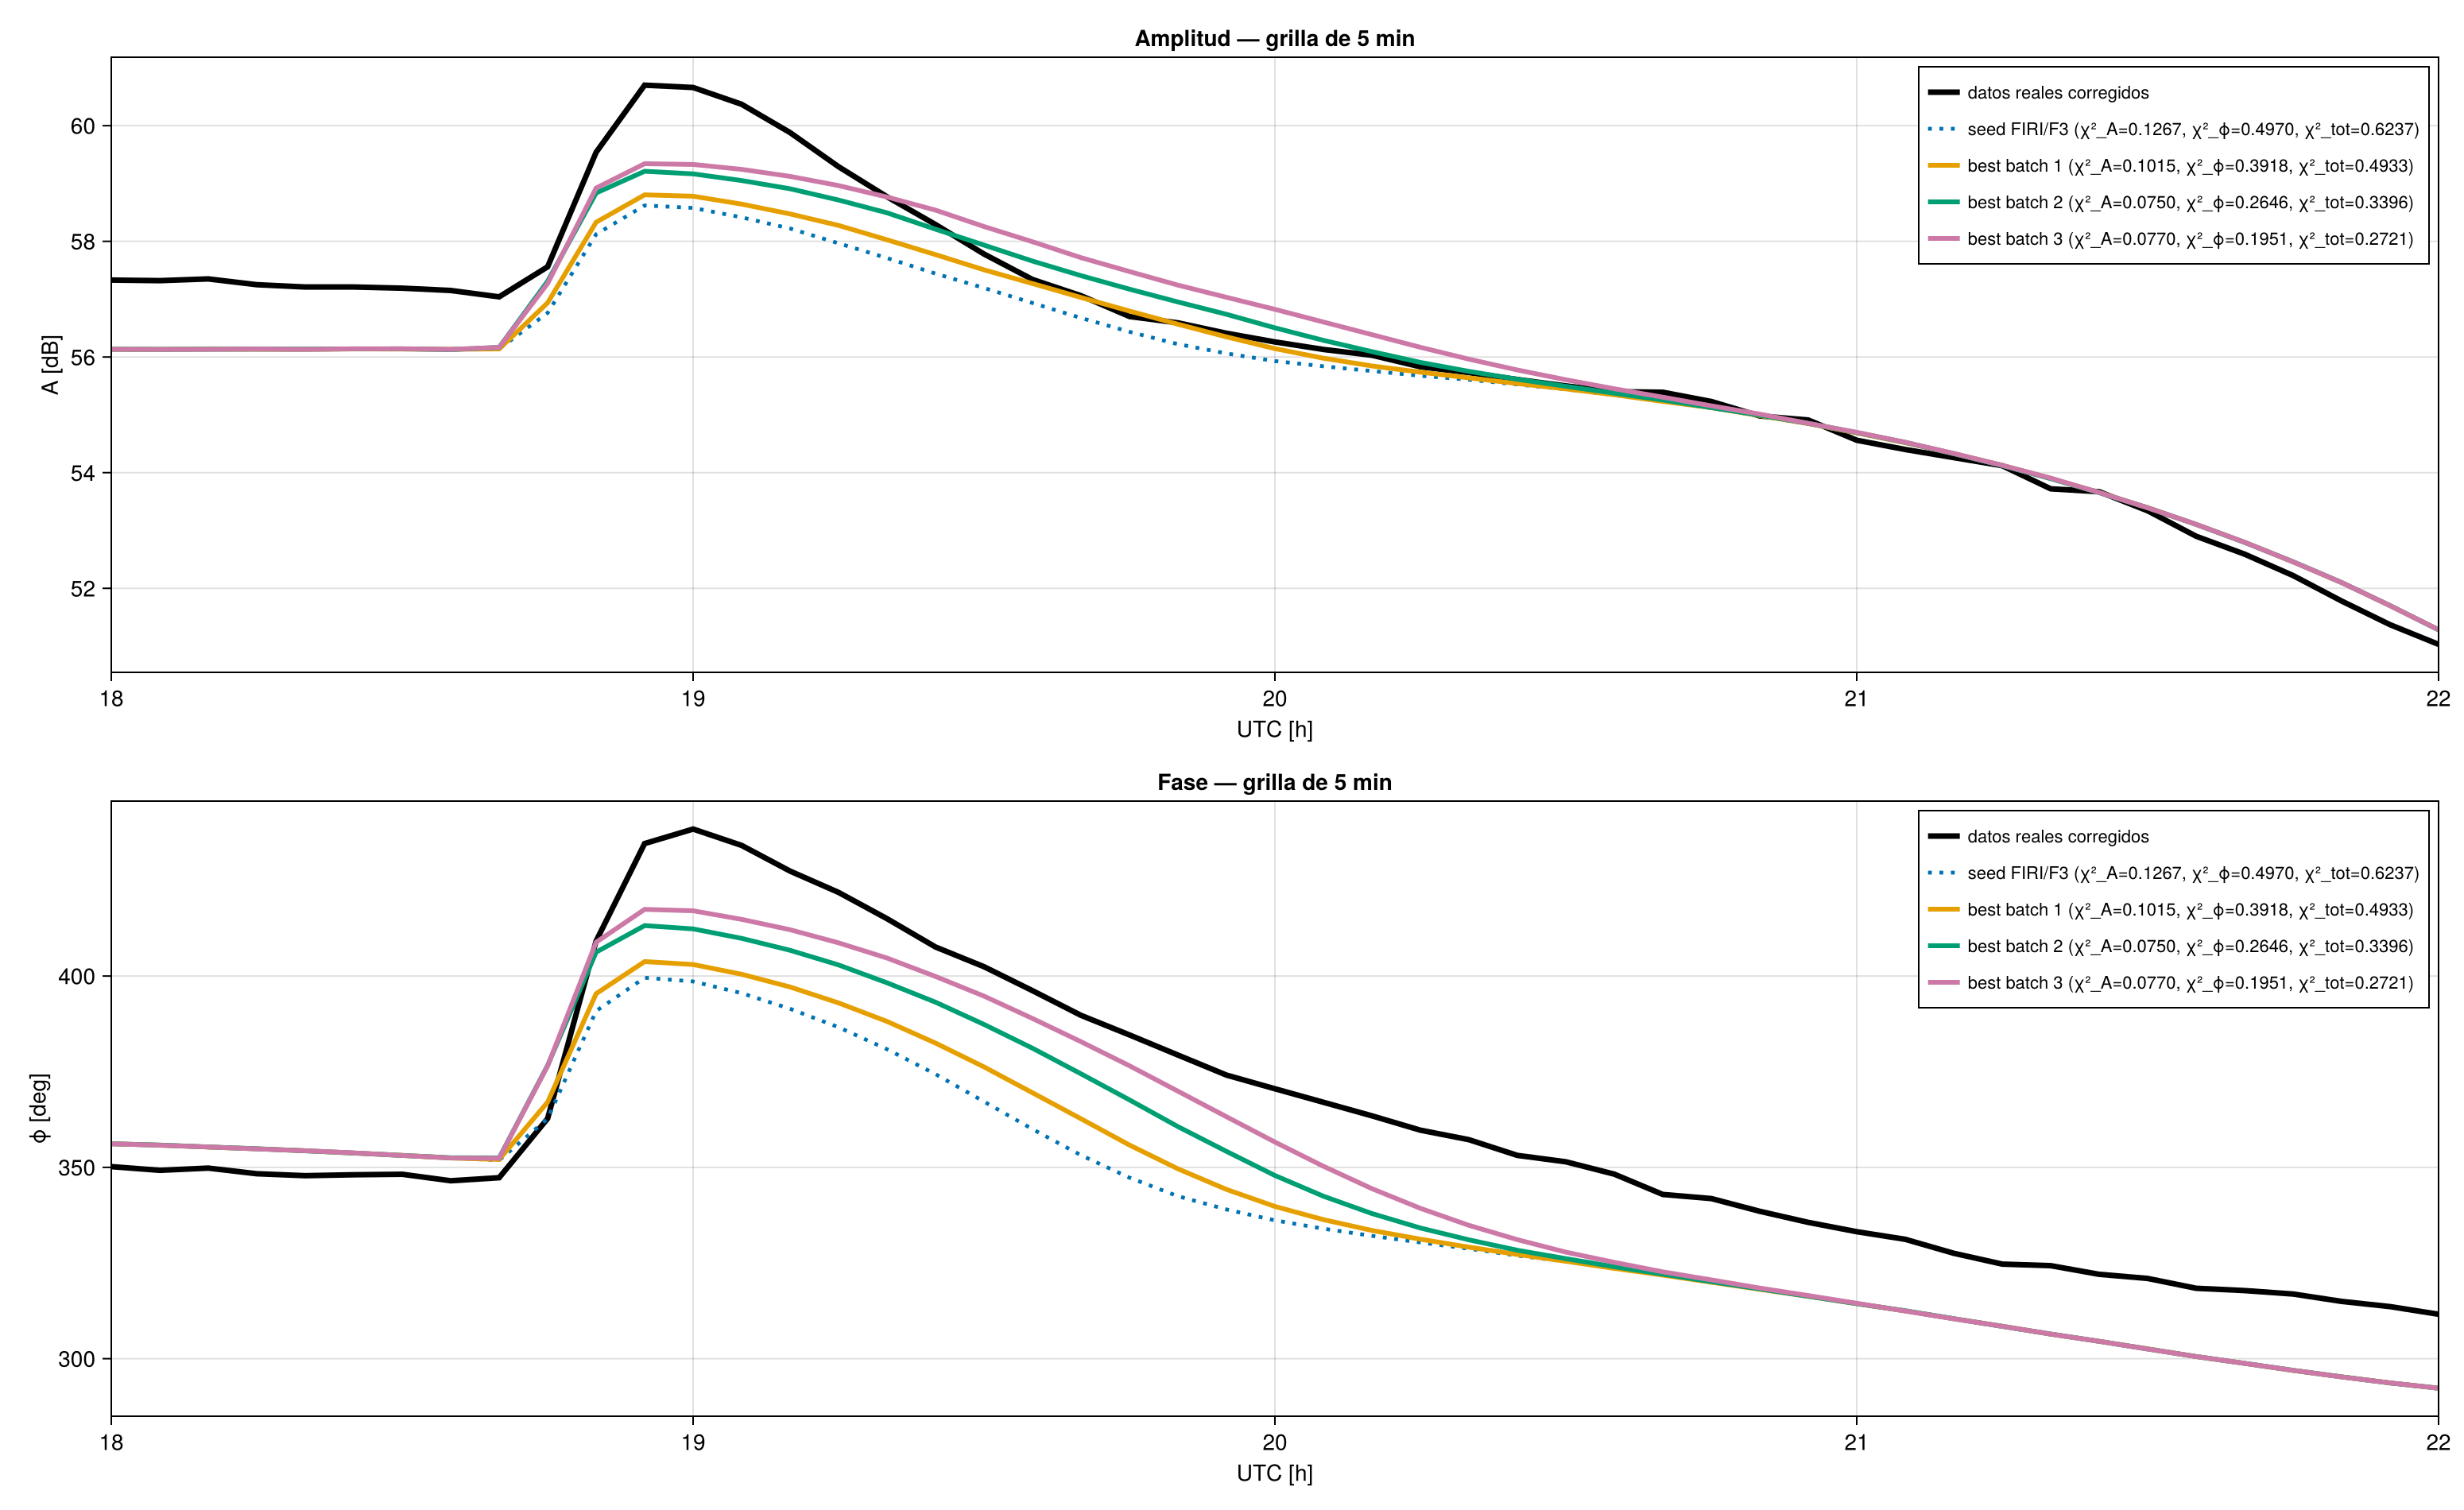

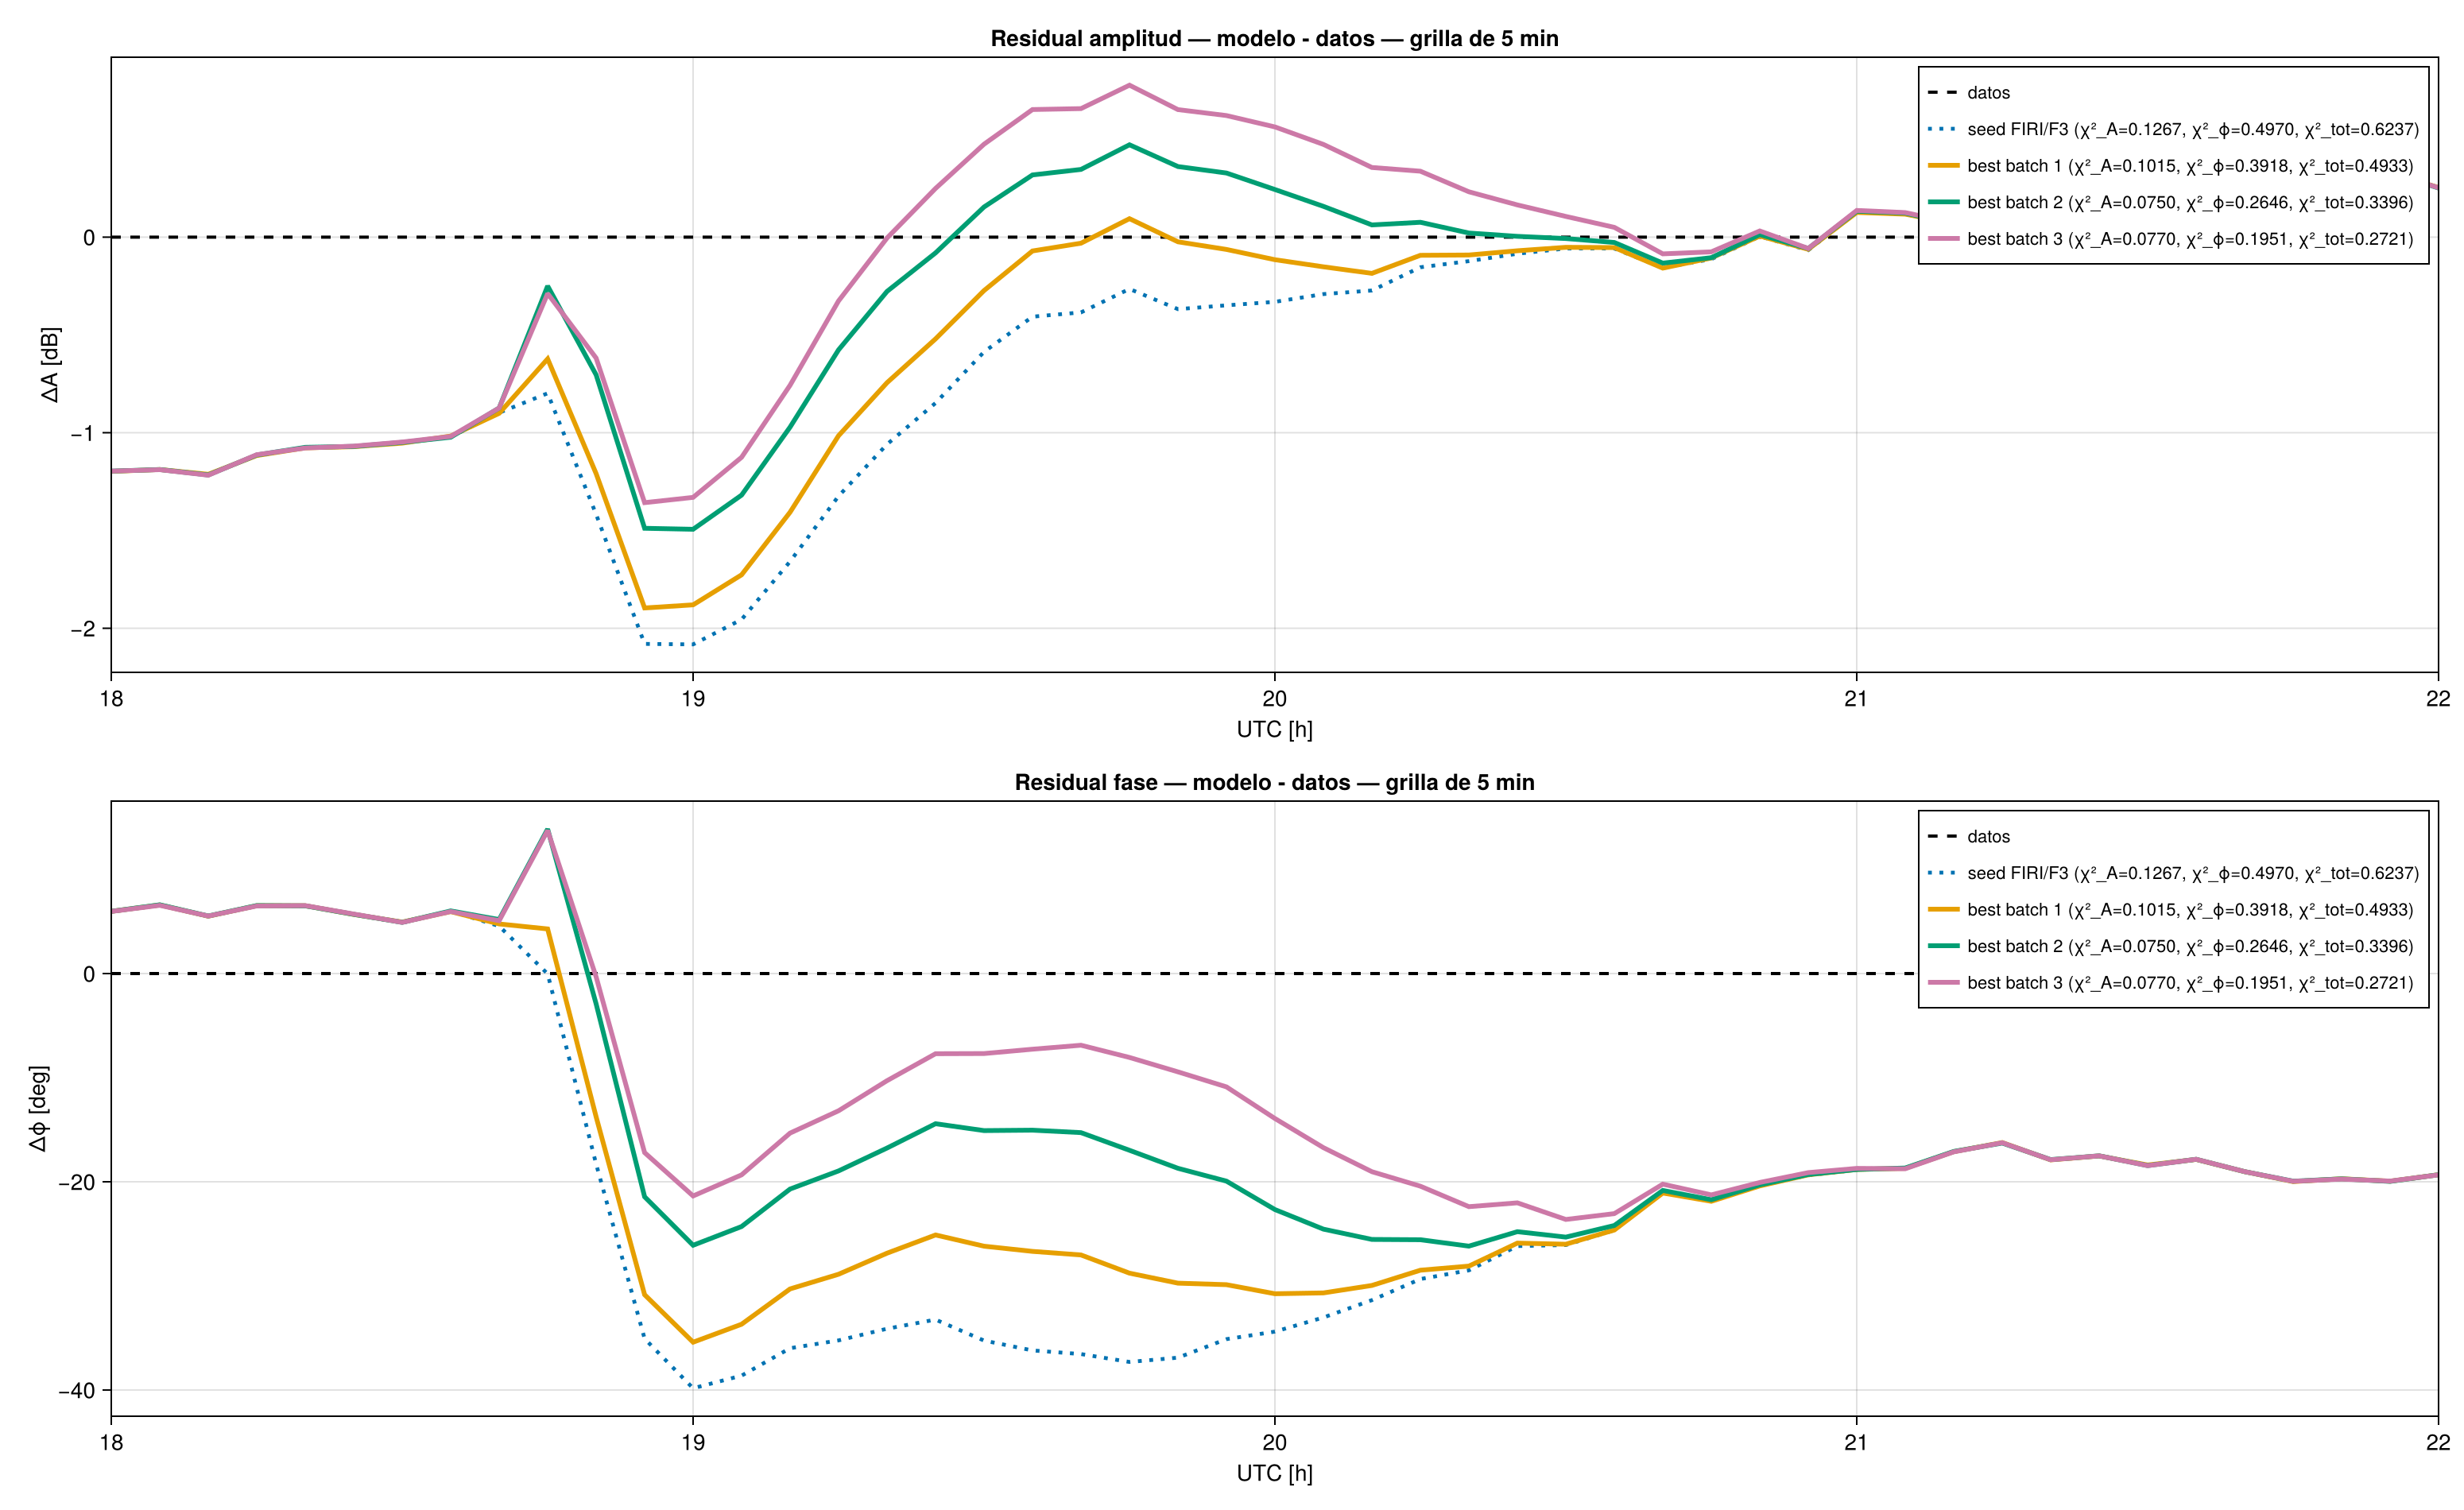

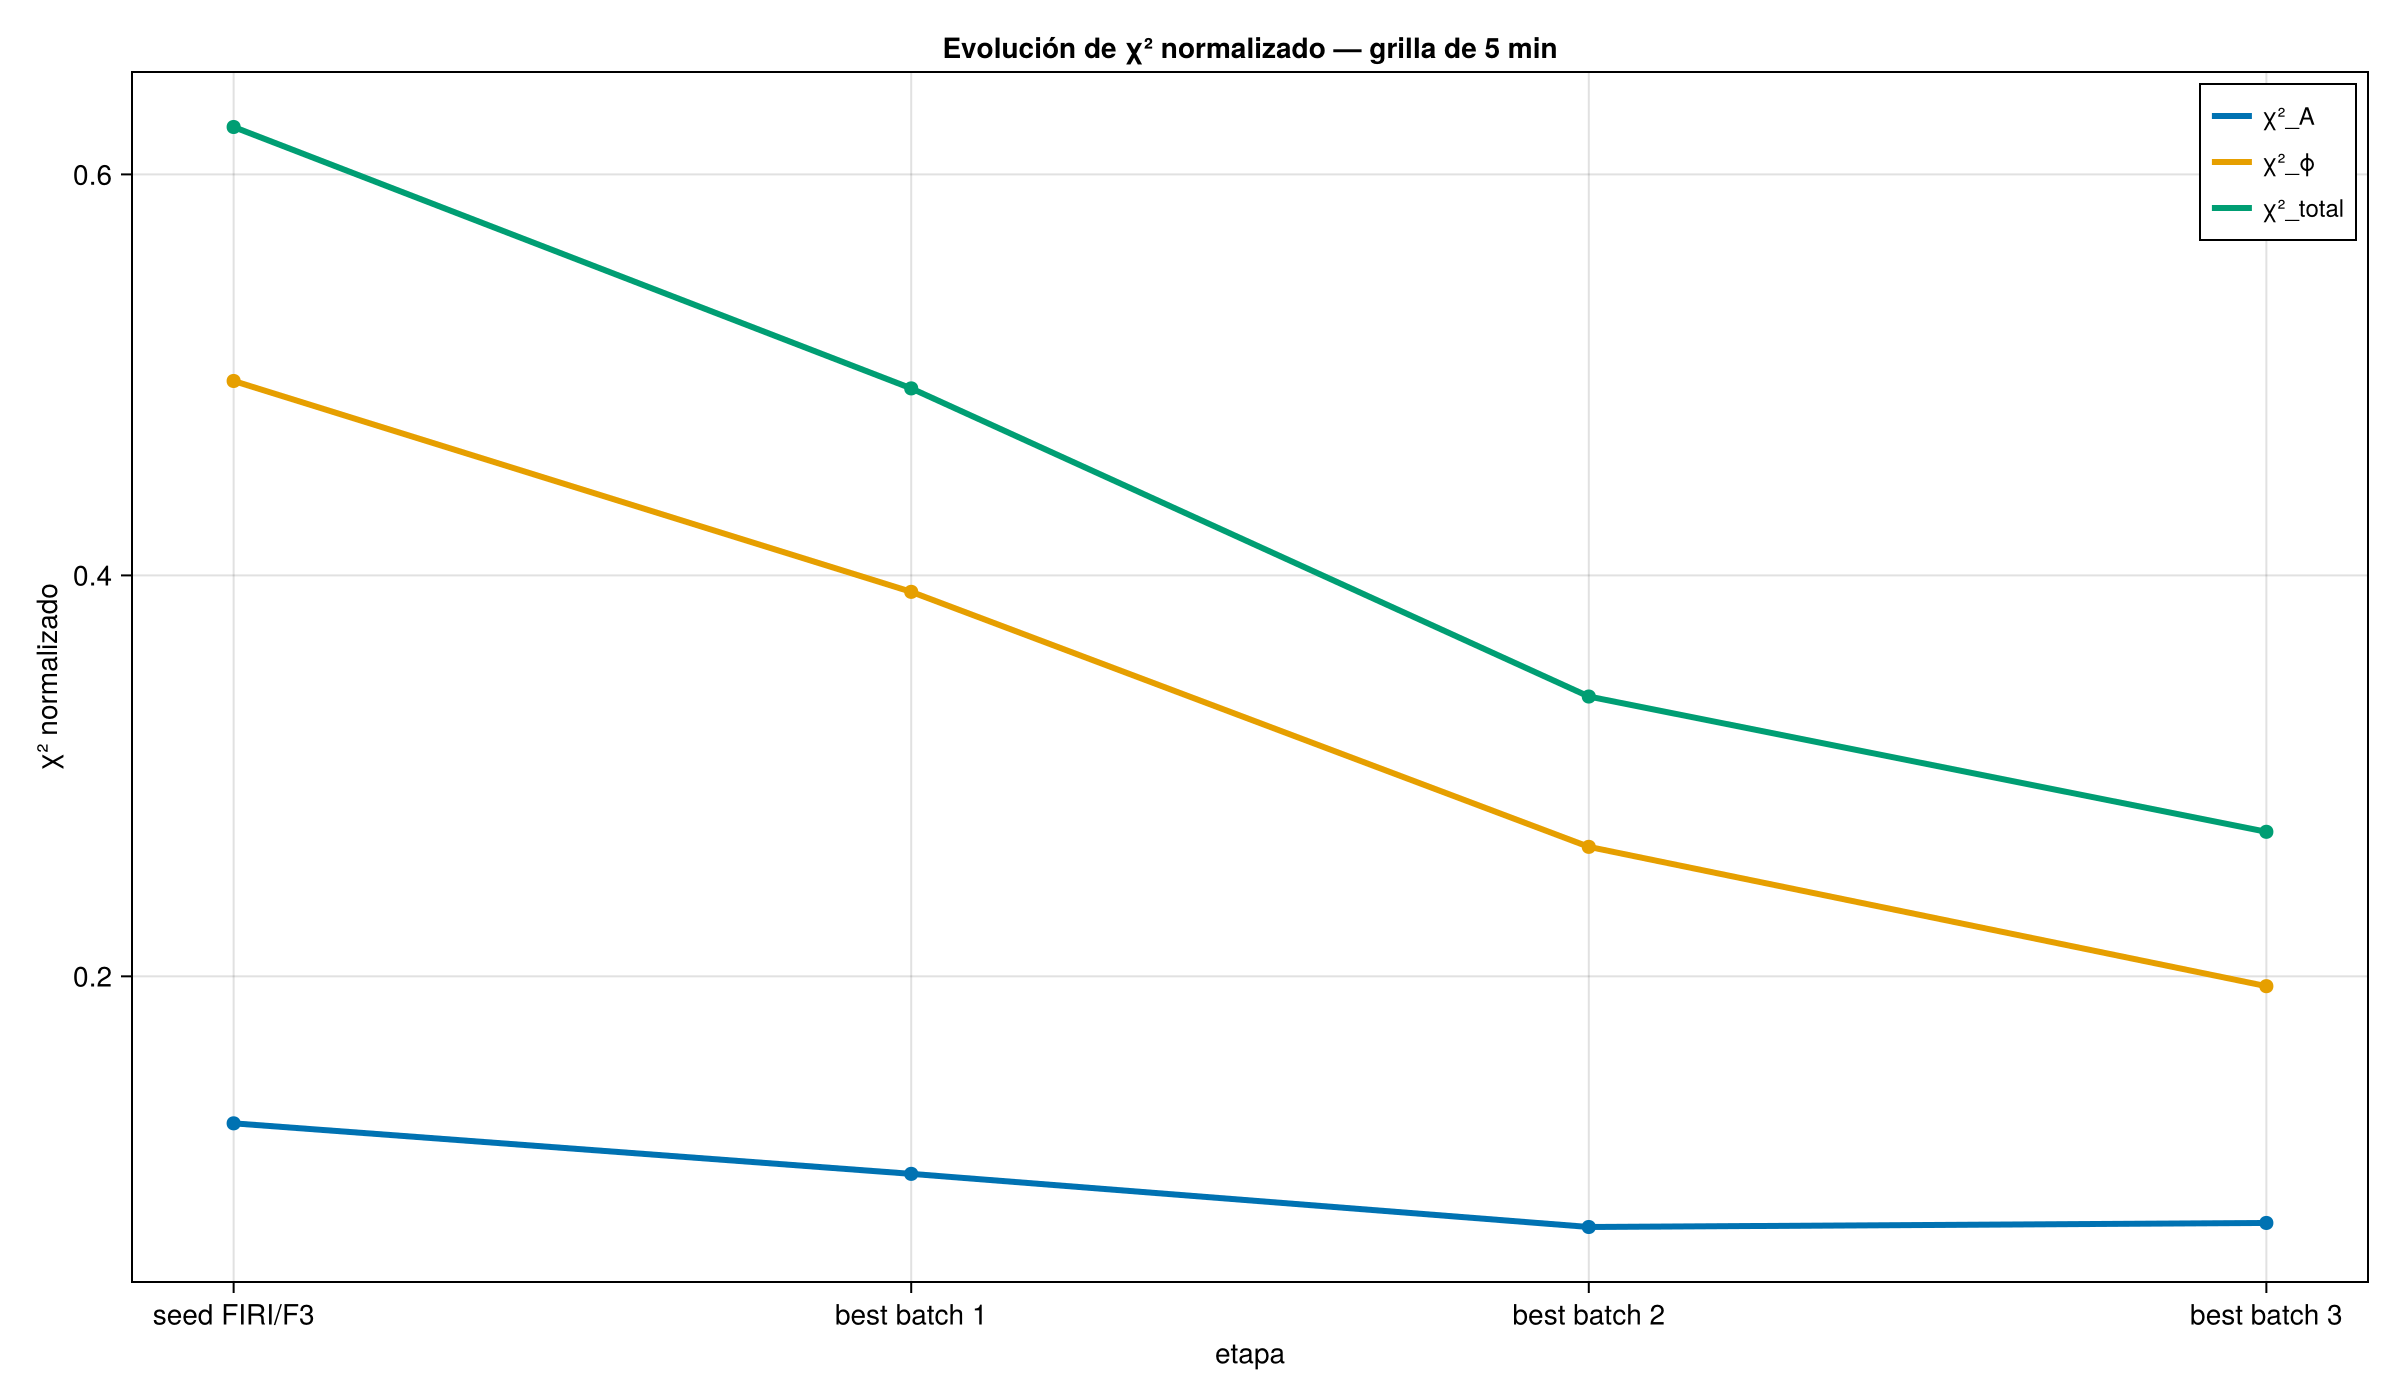

CairoMakie.Screen{IMAGE}


In [24]:
# ----------------------
# Figura 1: series
# ----------------------

fig1 = CM.Figure(size = (1550, 950))

axA = CM.Axis(
    fig1[1, 1],
    title = "Amplitud — grilla de 5 min",
    xlabel = "UTC [h]",
    ylabel = "A [dB]",
)

axP = CM.Axis(
    fig1[2, 1],
    title = "Fase — grilla de 5 min",
    xlabel = "UTC [h]",
    ylabel = "ϕ [deg]",
)

CM.lines!(
    axA,
    t_hours_plot,
    target_A_plot,
    color = :black,
    linewidth = 3.5,
    label = "datos reales corregidos",
)

CM.lines!(
    axP,
    t_hours_plot,
    target_phi_plot,
    color = :black,
    linewidth = 3.5,
    label = "datos reales corregidos",
)

for curve in curve_specs
    A = curves[curve.label][:A]
    phi = curves[curve.label][:phi]

    m = metric_dict[curve.display]
    lab = label_with_chi2(curve.display, m)

    ls = curve.label == :seed0 ? :dot : :solid
    lw = curve.label == :seed0 ? 2.4 : 3.0

    CM.lines!(
        axA,
        t_hours_plot,
        A,
        linestyle = ls,
        linewidth = lw,
        label = lab,
    )

    CM.lines!(
        axP,
        t_hours_plot,
        phi,
        linestyle = ls,
        linewidth = lw,
        label = lab,
    )
end

for ax in [axA, axP]
    CM.xlims!(ax, 18, 22)
    ax.xticks = 18:1:22
end

CM.axislegend(axA, position = :rt, labelsize = 11, framevisible = true)
CM.axislegend(axP, position = :rt, labelsize = 11, framevisible = true)

CM.save(
    joinpath(FIG_DIR_5MIN, "01_series_seed0_best1_best2_best3_5min.png"),
    fig1,
    px_per_unit = 2,
)

display(fig1)

# ----------------------
# Figura 2: residuales
# ----------------------

fig2 = CM.Figure(size = (1550, 950))

axRA = CM.Axis(
    fig2[1, 1],
    title = "Residual amplitud — modelo - datos — grilla de 5 min",
    xlabel = "UTC [h]",
    ylabel = "ΔA [dB]",
)

axRP = CM.Axis(
    fig2[2, 1],
    title = "Residual fase — modelo - datos — grilla de 5 min",
    xlabel = "UTC [h]",
    ylabel = "Δϕ [deg]",
)

CM.hlines!(
    axRA,
    [0.0],
    color = :black,
    linestyle = :dash,
    linewidth = 2.0,
    label = "datos",
)

CM.hlines!(
    axRP,
    [0.0],
    color = :black,
    linestyle = :dash,
    linewidth = 2.0,
    label = "datos",
)

for curve in curve_specs
    A = curves[curve.label][:A]
    phi = curves[curve.label][:phi]

    m = metric_dict[curve.display]
    lab = label_with_chi2(curve.display, m)

    ls = curve.label == :seed0 ? :dot : :solid
    lw = curve.label == :seed0 ? 2.4 : 3.0

    CM.lines!(
        axRA,
        t_hours_plot,
        A .- target_A_plot,
        linestyle = ls,
        linewidth = lw,
        label = lab,
    )

    CM.lines!(
        axRP,
        t_hours_plot,
        phi .- target_phi_plot,
        linestyle = ls,
        linewidth = lw,
        label = lab,
    )
end

for ax in [axRA, axRP]
    CM.xlims!(ax, 18, 22)
    ax.xticks = 18:1:22
end

CM.axislegend(axRA, position = :rt, labelsize = 11, framevisible = true)
CM.axislegend(axRP, position = :rt, labelsize = 11, framevisible = true)

CM.save(
    joinpath(FIG_DIR_5MIN, "02_residuales_seed0_best1_best2_best3_5min.png"),
    fig2,
    px_per_unit = 2,
)

display(fig2)

# ----------------------
# Figura 3: evolución de χ²
# ----------------------

fig3 = CM.Figure(size = (1200, 700))

axC = CM.Axis(
    fig3[1, 1],
    title = "Evolución de χ² normalizado — grilla de 5 min",
    xlabel = "etapa",
    ylabel = "χ² normalizado",
)

x = 1:nrow(metrics_5min_df)
labels_x = metrics_5min_df.curva

CM.lines!(axC, x, metrics_5min_df.chi2_A, linewidth = 3, label = "χ²_A")
CM.scatter!(axC, x, metrics_5min_df.chi2_A, markersize = 10)

CM.lines!(axC, x, metrics_5min_df.chi2_phi, linewidth = 3, label = "χ²_ϕ")
CM.scatter!(axC, x, metrics_5min_df.chi2_phi, markersize = 10)

CM.lines!(axC, x, metrics_5min_df.chi2_total, linewidth = 3, label = "χ²_total")
CM.scatter!(axC, x, metrics_5min_df.chi2_total, markersize = 10)

axC.xticks = (x, labels_x)

CM.axislegend(axC, position = :rt, labelsize = 12, framevisible = true)

CM.save(
    joinpath(FIG_DIR_5MIN, "03_chi2_evolucion_seed0_best1_best2_best3_5min.png"),
    fig3,
    px_per_unit = 2,
)

display(fig3)